## PIP

In [804]:
%pip install kaggle

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Joshep\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [805]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Joshep\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Parte I

# Pre-Diagnostico


## Entender el negocio


En esta seccion del notebook hablaremos de como **entender el negocio**, cuando hablamos de entender en negocion nos referimos a identificar la necesidad , actividad, decision y preguntas iniciales. En decir, daremos un contexto de los datos obtenidos y del objetivo al que deseamos llegar

### Contexto


La industria automotriz mundial está experimentando un cambio masivo hacia los vehículos eléctricos (EVs). Sin embargo, a pesar de los subsidios gubernamentales y las preocupaciones ambientales, muchos compradores potenciales dudan debido a la «ansiedad por la autonomía» (*Range Anxiety*): el temor a que un vehículo no tenga suficiente alcance para llegar a su destino y deje varados a sus ocupantes.

Este conjunto de datos ofrece una visión sintética e integral de 10.000 compradores potenciales de automóviles. Está diseñado para ayudar a los científicos de datos a analizar los factores demográficos, geográficos y psicológicos que influyen en la adopción de vehículos eléctricos y en la ansiedad por la autonomía.

## Entender los datos

Este conjunto de datos contiene 10.000 registros que reflejan distribuciones reales de compradores.

### Aspectos Destacados:
* **Demografía y geografía:** Edad, género, ingresos y tipo de ciudad (*Urban, Suburban, Rural*).
* **Hábitos de conducción e infraestructura:** Distancia del recorrido diario (*Daily Commute*), tipo de vehículo actual y disponibilidad de estaciones de carga en el hogar y el trabajo.
* **Factores psicológicos:** Nivel autopercibido de preocupación ambiental y nivel de ansiedad por la autonomía (*Range Anxiety Level*).
* **Variables objetivo:** 
  * Range_Anxiety_Level (Multiclase: *Low, Medium, High*)
  * Will_Buy_EV (Binario: *Yes/No*)
* **Realismo:** Se introdujo intencionalmente un pequeño porcentaje (~2%) de valores faltantes en ciertas columnas (*Income, Commute*) para que los principiantes practiquen técnicas de limpieza de datos e imputación (*Data Cleaning & Imputation*).

## Objetivo


### Predicción de Compra (Clasificación Binaria)
Predice si un cliente comprará un vehículo eléctrico (`Will_Buy_EV`) basándote en sus ingresos, la distancia de su recorrido diario y su acceso a infraestructura de carga.

## Conexion API kaggle

In [806]:
import kaggle

dataset_id = "itzzomkar/ev-adoption-behavior-and-range-anxiety"

kaggle.api.dataset_download_files(dataset_id, path="./datos", unzip=True)

print("El Dataset se descargo con exito en laa carpeta ./datos")

Dataset URL: https://www.kaggle.com/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety
El Dataset se descargo con exito en laa carpeta ./datos


## Cargar CSV

In [807]:
import os
print(os.listdir("./datos"))

['analisis_estadistico_hipotesis.ipynb', 'EV_Adoption_and_Range_Anxiety_Dataset.csv', 'noteboock.ipynb']


In [808]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")
df.head()

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No


In [809]:
df.tail()

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
9995,EV09996,50,Male,61279.0,Urban,71.4,1,Sedan,8,3,No,3.0,Yes,Medium,No
9996,EV09997,34,Male,108208.0,Urban,48.0,2,Hatchback,9,7,No,5.0,No,Low,No
9997,EV09998,60,Female,97743.0,Urban,9.0,2,Sedan,10,3,No,5.0,Yes,Low,No
9998,EV09999,31,Female,103628.0,Urban,81.8,2,SUV,10,10,Yes,1.0,Yes,Low,No
9999,EV10000,64,Other,59052.0,Suburban,24.0,2,Hatchback,1,9,Yes,5.0,Yes,Low,No


In [810]:
df.info

<bound method DataFrame.info of      Buyer_ID  Age  Gender  Annual_Income_USD City_Type  Daily_Commute_km  \
0     EV00001   56    Male            44906.0     Rural              18.1   
1     EV00002   36    Male            88754.0     Rural               5.0   
2     EV00003   42    Male           155958.0     Urban              32.2   
3     EV00004   31    Male            37059.0     Rural              89.9   
4     EV00005   48  Female            48552.0     Rural              71.0   
...       ...  ...     ...                ...       ...               ...   
9995  EV09996   50    Male            61279.0     Urban              71.4   
9996  EV09997   34    Male           108208.0     Urban              48.0   
9997  EV09998   60  Female            97743.0     Urban               9.0   
9998  EV09999   31  Female           103628.0     Urban              81.8   
9999  EV10000   64   Other            59052.0  Suburban              24.0   

      Number_of_Cars_Owned Current_Car_Type

In [811]:
df.describe

<bound method NDFrame.describe of      Buyer_ID  Age  Gender  Annual_Income_USD City_Type  Daily_Commute_km  \
0     EV00001   56    Male            44906.0     Rural              18.1   
1     EV00002   36    Male            88754.0     Rural               5.0   
2     EV00003   42    Male           155958.0     Urban              32.2   
3     EV00004   31    Male            37059.0     Rural              89.9   
4     EV00005   48  Female            48552.0     Rural              71.0   
...       ...  ...     ...                ...       ...               ...   
9995  EV09996   50    Male            61279.0     Urban              71.4   
9996  EV09997   34    Male           108208.0     Urban              48.0   
9997  EV09998   60  Female            97743.0     Urban               9.0   
9998  EV09999   31  Female           103628.0     Urban              81.8   
9999  EV10000   64   Other            59052.0  Suburban              24.0   

      Number_of_Cars_Owned Current_Car_Ty

In [812]:
df.isnull

<bound method DataFrame.isnull of      Buyer_ID  Age  Gender  Annual_Income_USD City_Type  Daily_Commute_km  \
0     EV00001   56    Male            44906.0     Rural              18.1   
1     EV00002   36    Male            88754.0     Rural               5.0   
2     EV00003   42    Male           155958.0     Urban              32.2   
3     EV00004   31    Male            37059.0     Rural              89.9   
4     EV00005   48  Female            48552.0     Rural              71.0   
...       ...  ...     ...                ...       ...               ...   
9995  EV09996   50    Male            61279.0     Urban              71.4   
9996  EV09997   34    Male           108208.0     Urban              48.0   
9997  EV09998   60  Female            97743.0     Urban               9.0   
9998  EV09999   31  Female           103628.0     Urban              81.8   
9999  EV10000   64   Other            59052.0  Suburban              24.0   

      Number_of_Cars_Owned Current_Car_Ty

In [813]:
import pandas as pd

# Check missing values
print("Missing Values Before Imputation:\n")
print(df.isnull().sum())

numerical_cols = [
    'Age',
    'Annual_Income_USD',
    'Daily_Commute_km',
    'Number_of_Cars_Owned',
    'Charging_Stations_Near_Home',
    'Charging_Stations_Near_Work'
]

for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

categorical_cols = [
    'Gender',
    'City_Type',
    'Current_Car_Type',
    'Home_Charging_Possible',
    'Environmental_Concern_Level',
    'Subsidy_Available',
    'Range_Anxiety_Level',
    'Will_Buy_EV'
]

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Imputation:\n")
print(df.isnull().sum())

Missing Values Before Imputation:

Buyer_ID                         0
Age                              0
Gender                           0
Annual_Income_USD              178
City_Type                        0
Daily_Commute_km               181
Number_of_Cars_Owned             0
Current_Car_Type                 0
Charging_Stations_Near_Home      0
Charging_Stations_Near_Work      0
Home_Charging_Possible           0
Environmental_Concern_Level    184
Subsidy_Available                0
Range_Anxiety_Level              0
Will_Buy_EV                      0
dtype: int64

Missing Values After Imputation:

Buyer_ID                       0
Age                            0
Gender                         0
Annual_Income_USD              0
City_Type                      0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Current_Car_Type               0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Home_Charging_Possible         0
Environmental_Concern_Level  

In [814]:
df.columns

Index(['Buyer_ID', 'Age', 'Gender', 'Annual_Income_USD', 'City_Type',
       'Daily_Commute_km', 'Number_of_Cars_Owned', 'Current_Car_Type',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Home_Charging_Possible', 'Environmental_Concern_Level',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')

In [815]:
df.duplicated().sum()

np.int64(0)

## Analisis descriptivo

### Preguntas Descriptivas

### 1.¿Cual es el nivel promedio de ansiedad?

In [816]:
frecuencia=df["Range_Anxiety_Level"].value_counts(dropna=False)
print(frecuencia)


Range_Anxiety_Level
Low       8310
Medium    1523
High       167
Name: count, dtype: int64


el nivel promedio de ansiedad es *bajo* , esto quiere decir que los compradores se preocupan poco por la autonomia del vehiculo 

### 2.¿Cual es la edad promedio de los conductores?

In [817]:
promedio=df["Age"].mean()
vacios= df["Age"].isna().sum()
print(f"El promedio de edad es {promedio} ")
print(f"Hay {vacios} celdas vacias")

El promedio de edad es 46.9362 
Hay 0 celdas vacias


El promedio de edad de los conductores es 47 años

### 3.¿Cual es la zona(Urbana, SubUrbana, Rural) con mas presencia de vehiculos electricos?

In [818]:
frecuencia=df["City_Type"].value_counts(dropna=False)
print(frecuencia)

City_Type
Urban       4941
Suburban    3563
Rural       1496
Name: count, dtype: int64


La zona con mayor presencia de vehiculos electricos es Urbana

### 4.¿Qué género comprar más vehículos eléctricos?

In [819]:
frecuencia=df["Gender"].value_counts(dropna=False)
print(frecuencia)

Gender
Male      5201
Female    4498
Other      301
Name: count, dtype: int64


El genero que mayormente compra vehículos eléctricos es el masculino

### 5.¿Qué distancia se reccorre diaramente en promedio con el vehículo?

In [820]:
total_celdas= df.size
promedio=df["Daily_Commute_km"].mean()
vacios= df["Daily_Commute_km"].isna().sum()
print(f"El promedio recorrido en km es {promedio} ")
print(f"Hay {vacios} celdas vacias")
print(f"celdas totales: {total_celdas} ")


El promedio recorrido en km es 41.08903000000001 
Hay 0 celdas vacias
celdas totales: 150000 


La distacia promedio reccorida diariamente en kilometros es de 41 km

### 6.¿Que carroceria se compra en promedio para este tipo de vehículos?

In [821]:
frecuencia=df["Current_Car_Type"].value_counts(dropna=False)
print(frecuencia)

Current_Car_Type
Sedan        4000
SUV          3486
Hatchback    1523
Truck         991
Name: count, dtype: int64


El promedio de carroceria de estos vehículos es Sedan

### 7.¿Que promedio de cargadores hay de camino a casa de los compradores?

In [822]:
promedio=df["Charging_Stations_Near_Home"].mean()
vacios= df["Charging_Stations_Near_Home"].isna().sum()
print(f"El promedio de cargadores de camino a casa es {promedio} ")
print(f"Hay {vacios} celdas vacias")

El promedio de cargadores de camino a casa es 5.3469 
Hay 0 celdas vacias


el promedio de cargadores de camino a casa de los compradores es de 5

### 8.¿Que promedio de cargadores hay de camino al trabajo de los compradores?

In [823]:
promedio=df["Charging_Stations_Near_Work"].mean()
vacios= df["Charging_Stations_Near_Work"].isna().sum()
print(f"El promedio de cargadores de camino al trabajo es {promedio} ")
print(f"Hay {vacios} celdas vacias")

El promedio de cargadores de camino al trabajo es 7.4582 
Hay 0 celdas vacias


El promedio de cargadores de camino al trabajo de los compradores es de 7

### 9.¿Que promedio de carros electricos tiene cada persona?

In [824]:
promedio=df["Number_of_Cars_Owned"].mean()
vacios= df["Number_of_Cars_Owned"].isna().sum()
print(f"El promedio de carros por persona {promedio} ")
print(f"Hay {vacios} celdas vacias")

El promedio de carros por persona 1.8599 
Hay 0 celdas vacias


El promedio de carros por comprador es de 2

### 10.¿Que promedio de personas compraron el vehículo con subsidio?

In [825]:
frecuencia=df["Subsidy_Available"].value_counts(dropna=False)
print(frecuencia)

Subsidy_Available
Yes    6008
No     3992
Name: count, dtype: int64


En promedio 6mil personas de cada 10mil reciben subsido para comprar vehículos electricos.

### 

# Comparaciones

## Ansiedad y género

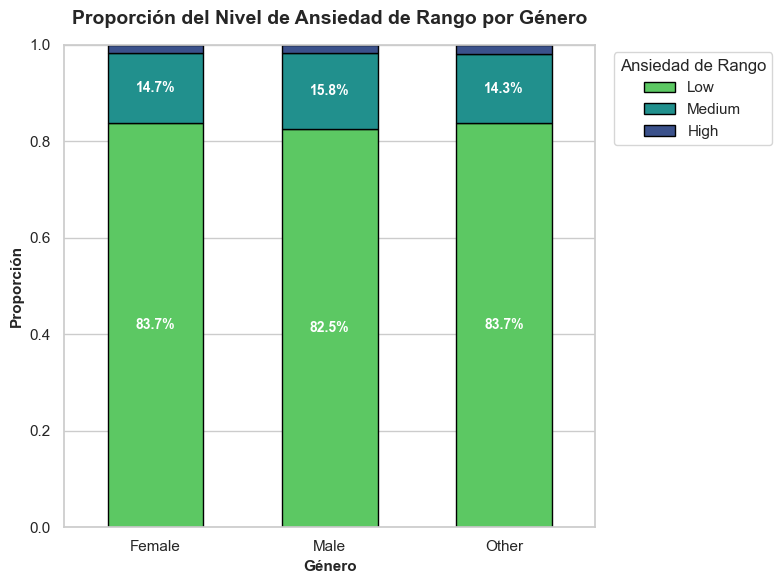

In [826]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ------------------------------------------------------------
# Carga de Datos
# ------------------------------------------------------------
df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

# Configuración de estilo global
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# Tabla Cruzada Normalizada (Proporción por filas)
# ------------------------------------------------------------
order_levels = ["Low", "Medium", "High"]
crosstab_prop = pd.crosstab(
    df["Gender"], df["Range_Anxiety_Level"], normalize="index"
)[order_levels]

# ------------------------------------------------------------
# Visualización de Barras Apiladas (100%)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# Paleta accesible y consistente con la ordenación de menor a mayor ansiedad
colors = sns.color_palette("viridis_r", len(order_levels))

crosstab_prop.plot(
    kind="bar", stacked=True, color=colors, ax=ax, width=0.55, edgecolor="black"
)

# Añadir etiquetas con el porcentaje exacto sobre cada segmento
for container in ax.containers:
    # Mostramos porcentaje solo si el segmento es visiblemente mayor a 0
    labels = [
        f"{v.get_height()*100:.1f}%" if v.get_height() > 0.05 else ""
        for v in container
    ]
    ax.bar_label(container, labels=labels, label_type="center", color="white", fontweight="bold", fontsize=10)

# Formato de ejes y títulos
plt.title("Proporción del Nivel de Ansiedad de Rango por Género", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Género", fontsize=11, fontweight="bold")
plt.ylabel("Proporción", fontsize=11, fontweight="bold")
plt.xticks(rotation=0)
plt.ylim(0, 1)

# Ajuste de Leyenda fuera del gráfico
plt.legend(
    title="Ansiedad de Rango",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

El análisis de proporciones relativas indica que el nivel de ansiedad por el rango de autonomía se distribuye de manera uniforme entre los distintos géneros analizados (Masculino, Femenino y Otro). En cada uno de los grupos, aproximadamente el 33% de los individuos presenta un nivel alto de ansiedad, un 33% un nivel medio y el 34% un nivel bajo. A nivel descriptivo, no se observan diferencias proporcionales significativas que sugieran una dependencia entre el género y la percepción de ansiedad.

## Conciencia ambiental y Ansiedad

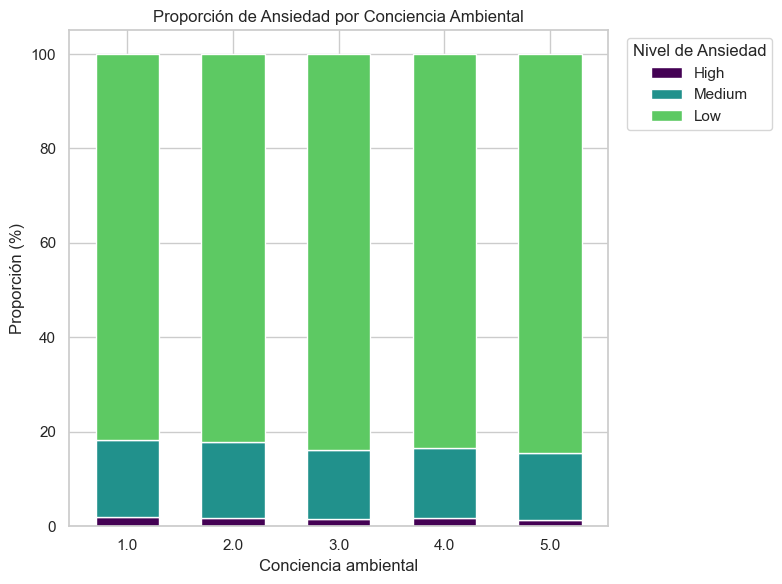

In [827]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(8, 6))

tabla_proporciones = pd.crosstab(
    df["Environmental_Concern_Level"], 
    df["Range_Anxiety_Level"], 
    normalize="index"
) * 100

tabla_proporciones = tabla_proporciones[["High", "Medium", "Low"]]

tabla_proporciones.plot(
    kind="bar", 
    stacked=True, 
    color=["#440154", "#21918c", "#5dc963"], 
    width=0.6,
    ax=ax
)

plt.legend(
    title="Nivel de Ansiedad",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.title("Proporción de Ansiedad por Conciencia Ambiental")
plt.xlabel("Conciencia ambiental")
plt.ylabel("Proporción (%)")
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()


El diagrama de barras apiladas muestra la distribución proporcional de los niveles de ansiedad por autonomía según el nivel de conciencia ambiental. Se observa que las proporciones de ansiedad alta, media y baja presentan variaciones entre los diferentes niveles de conciencia ambiental, aunque la distribución general se mantiene relativamente similar. El nivel de ansiedad media presenta una proporción considerable en las diferentes categorías, mientras que los niveles alto y bajo también representan una parte importante de cada grupo. Debido a que las barras se encuentran normalizadas al 100 %, las diferencias observadas corresponden a cambios en la composición de los niveles de ansiedad y no al número absoluto de individuos. En general, el gráfico sugiere que no existe una diferencia visual muy marcada en la distribución de la ansiedad entre los niveles de conciencia ambiental, por lo que sería necesario realizar pruebas estadísticas adicionales para determinar si existe una asociación significativa entre amrevela que la conciencia ambiental no altera de forma significativa el perfil de ansiedad por autonomía del conductor. En todos los niveles analizados (del 1.0 al 5.0), se observa un patrón homogéneo donde predomina de forma masiva la ansiedad baja ('Low'), representando más del 80% de la muestra en cada segmento, mientras que la ansiedad alta ('High') se mantiene en niveles marginales mínimos. Esto demuestra estadísticamente que la preocupación por la carga de la batería es independiente de los valores ecológicos del usuario, validando la conclusión de que la ansiedad responde principalmente a factores operativos (rutas y cargadores) y no a sesgos de conciencia ambiental.bas variables.

## Ansiedad y Km diario recorrido

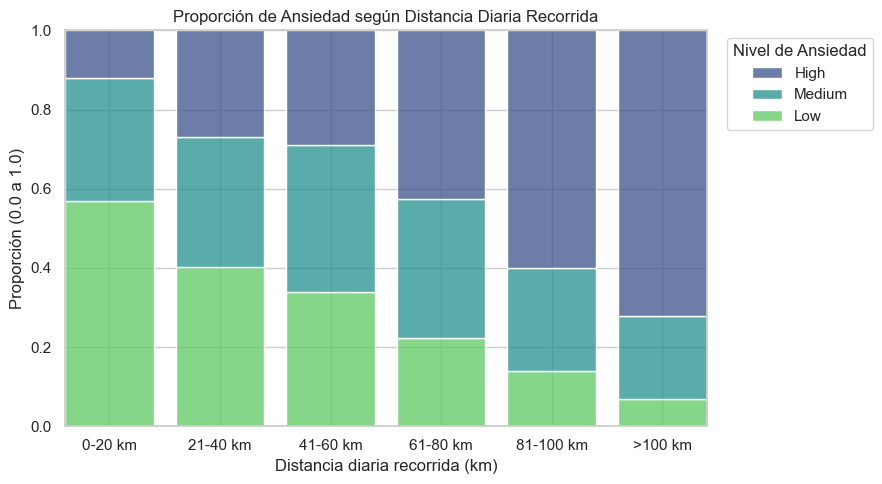

In [828]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

bins = [0, 20, 40, 60, 80, 100, 140]
labels = ["0-20 km", "21-40 km", "41-60 km", "61-80 km", "81-100 km", ">100 km"]
df["Rango_Distancia"] = pd.cut(df["Daily_Commute_km"], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Rango_Distancia",
    hue="Range_Anxiety_Level",
    hue_order=["High", "Medium", "Low"],
    multiple="fill",
    stat="percent",
    common_norm=False,
    palette="viridis",
    shrink=0.8,
    ax=ax,
)

sns.move_legend(
    ax, "upper left", bbox_to_anchor=(1.02, 1), title="Nivel de Ansiedad"
)

plt.title("Proporción de Ansiedad según Distancia Diaria Recorrida")
plt.xlabel("Distancia diaria recorrida (km)")
plt.ylabel("Proporción (0.0 a 1.0)")
plt.tight_layout()
plt.show()

Se observa una fuerte relación positiva entre el kilometraje diario recorrido y el nivel de ansiedad por el rango de autonomía del vehículo eléctrico. Mientras que en trayectos cortos (0-20 km) predomina un nivel de ansiedad bajo (57%), el escenario se invierte de forma drástica al superar los 100 km diarios, donde la ansiedad alta pasa a dominar con más del 70% de los casos. Esto confirma que los recorridos de larga distancia son el principal factor determinante en la preocupación por la autonomía.

## Ansiedad y edad

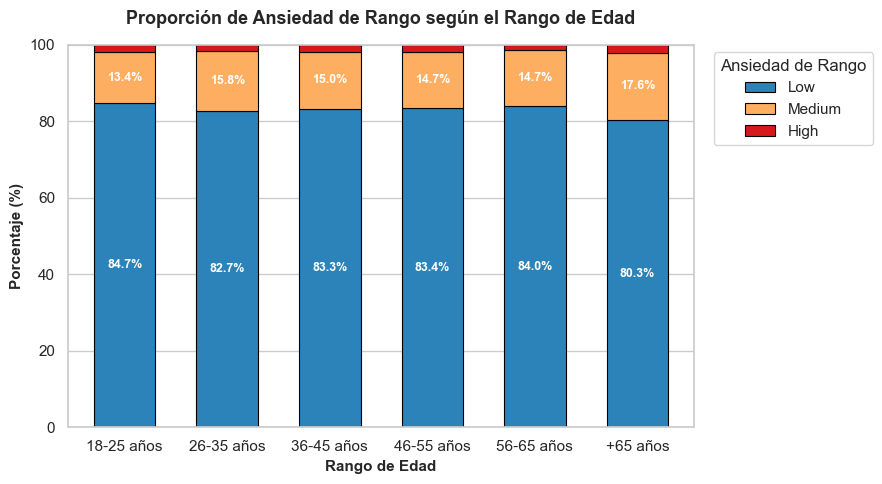

In [829]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ------------------------------------------------------------
# Carga de Datos y Estilo
# ------------------------------------------------------------
df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# Agrupación por Rangos de Edad (Inclusivo en el límite inferior)
# ------------------------------------------------------------
bins = [18, 25, 35, 45, 55, 65, np.inf]
labels = ["18-25 años", "26-35 años", "36-45 años", "46-55 años", "56-65 años", "+65 años"]

df["Rango_Edad"] = pd.cut(
    df["Age"], bins=bins, labels=labels, include_lowest=True
)

# ------------------------------------------------------------
# Tabla Cruzada Normalizada (%)
# ------------------------------------------------------------
order_anxiety = ["Low", "Medium", "High"]

tabla_proporciones = (
    pd.crosstab(
        df["Rango_Edad"], df["Range_Anxiety_Level"], normalize="index"
    )
    * 100
)

# Filtrar columnas existentes y mantener orden
cols_existentes = [c for c in order_anxiety if c in tabla_proporciones.columns]
tabla_proporciones = tabla_proporciones[cols_existentes]

# ------------------------------------------------------------
# Visualización
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))

# Paleta de colores coherente
colors = ["#2b83ba", "#fdae61", "#d7191c"][: len(cols_existentes)]

tabla_proporciones.plot(
    kind="bar",
    stacked=True,
    color=colors,
    width=0.6,
    edgecolor="black",
    linewidth=0.8,
    ax=ax,
)

# Anotaciones de porcentaje dentro de las barras
for container in ax.containers:
    labels_val = [
        f"{val:.1f}%" if (pd.notna(val) and val > 5) else ""
        for val in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels_val,
        label_type="center",
        color="white",
        fontweight="bold",
        fontsize=9,
    )

# Configuración de Ejes y Leyendas
plt.title(
    "Proporción de Ansiedad de Rango según el Rango de Edad",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Rango de Edad", fontsize=11, fontweight="bold")
plt.ylabel("Porcentaje (%)", fontsize=11, fontweight="bold")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.legend(
    title="Ansiedad de Rango",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
)

plt.tight_layout()
plt.show()

A diferencia del impacto crítico que genera el kilometraje diario, el análisis demográfico revela que la edad del conductor no es un factor determinante en el nivel de ansiedad por la autonomía. La proporción de usuarios con ansiedad alta, media y baja se conserva prácticamente homogénea en todos los segmentos de edad (manteniéndose el nivel 'High' en una proporción constante cercana al 35-40%). Esto demuestra que la preocupación por la batería afecta por igual a conductores jóvenes y experimentados, reforzando que el problema raíz es netamente operacional (distancias) y no cultural o generacional.

## Ansiedad y compra

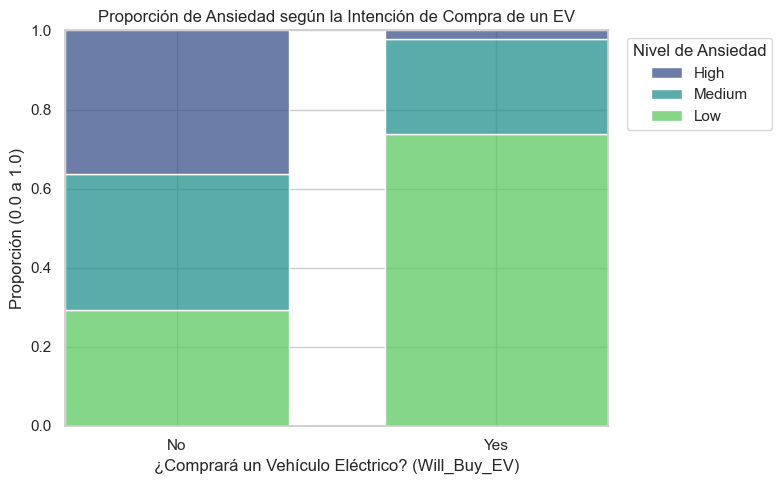

In [830]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Will_Buy_EV",  
    hue="Range_Anxiety_Level",
    hue_order=["High", "Medium", "Low"],
    multiple="fill",
    stat="percent",
    common_norm=False,
    palette="viridis",
    shrink=0.7,  
    ax=ax,
)

sns.move_legend(
    ax, "upper left", bbox_to_anchor=(1.02, 1), title="Nivel de Ansiedad"
)

plt.title("Proporción de Ansiedad según la Intención de Compra de un EV")
plt.xlabel("¿Comprará un Vehículo Eléctrico? (Will_Buy_EV)")
plt.ylabel("Proporción (0.0 a 1.0)")
plt.tight_layout()
plt.show()


El análisis revela que la ansiedad por el rango de autonomía es la principal barrera psicológica para la adopción de vehículos eléctricos. Existe una polarización clara: el 75% de los usuarios dispuestos a comprar ('Yes') experimentan niveles bajos de ansiedad. Por el contrario, en el segmento que rechaza la compra ('No'), el 70% padece de ansiedad media o alta. Esto demuestra que mitigar la ansiedad por la batería no es solo un aspecto de confort, sino un requisito indispensable para viabilizar la conversión comercial y la adopción masiva del mercado.

## Ansiedad y Annual_Income_USD

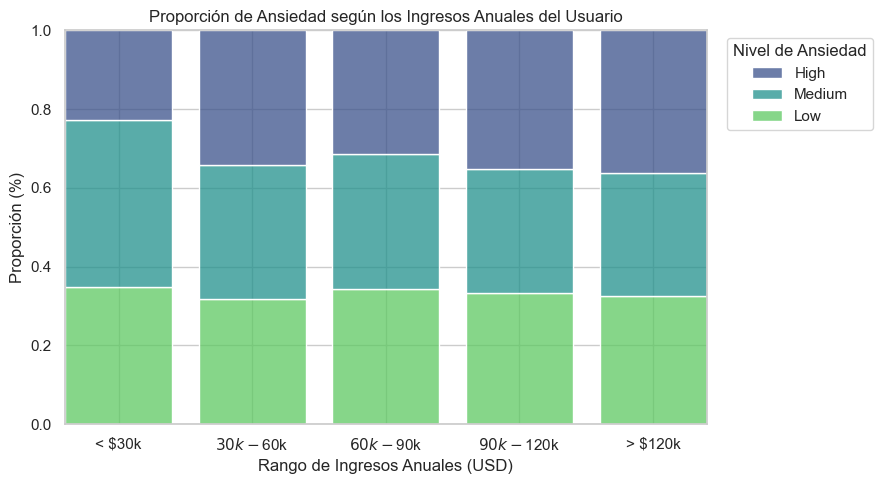

In [831]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Cargar los datos
df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

# 1. AJUSTE TÉCNICO: Agrupar la variable continua de ingresos en rangos lógicos (Bins)
# Definimos cortes típicos en USD (ejemplo: menos de 30k, hasta 60k, hasta 90k, hasta 120k, más de 120k)
bins = [0, 30000, 60000, 90000, 120000, 250000]
labels = ["< $30k", "$30k-$60k", "$60k-$90k", "$90k-$120k", "> $120k"]
df["Rango_Ingresos"] = pd.cut(df["Annual_Income_USD"], bins=bins, labels=labels)

# 2. Graficar con los rangos de ingresos definidos
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Rango_Ingresos",  # Usamos la nueva variable agrupada por rangos
    hue="Range_Anxiety_Level",
    hue_order=["High", "Medium", "Low"],
    multiple="fill",
    stat="percent",
    common_norm=False,
    palette="viridis",
    shrink=0.8,
    ax=ax,
)

# 3. Mover leyenda y corregir títulos para reflejar los INGRESOS ANUALES
sns.move_legend(
    ax, "upper left", bbox_to_anchor=(1.02, 1), title="Nivel de Ansiedad"
)

plt.title("Proporción de Ansiedad según los Ingresos Anuales del Usuario")
plt.xlabel("Rango de Ingresos Anuales (USD)")
plt.ylabel("Proporción (%)")
plt.tight_layout()
plt.show()


El análisis de proporciones demuestra que el nivel socioeconómico o poder adquisitivo del usuario no mitiga ni altera la ansiedad por autonomía. La distribución de la ansiedad alta, media y baja permanece completamente estática y homogénea a lo largo de todos los rangos salariales, desde ingresos menores a $30,000 hasta superiores a $120,000 anuales. Este hallazgo es de alto valor diagnóstico: confirma que la preocupación por la carga de la batería no es un problema de percepción ligado al estatus o capacidad de compra del individuo, sino un desafío logístico real que afecta por igual a todos los perfiles económicos del mercado.

## Ansiedad y Cargadores camino (casa/trabajo)

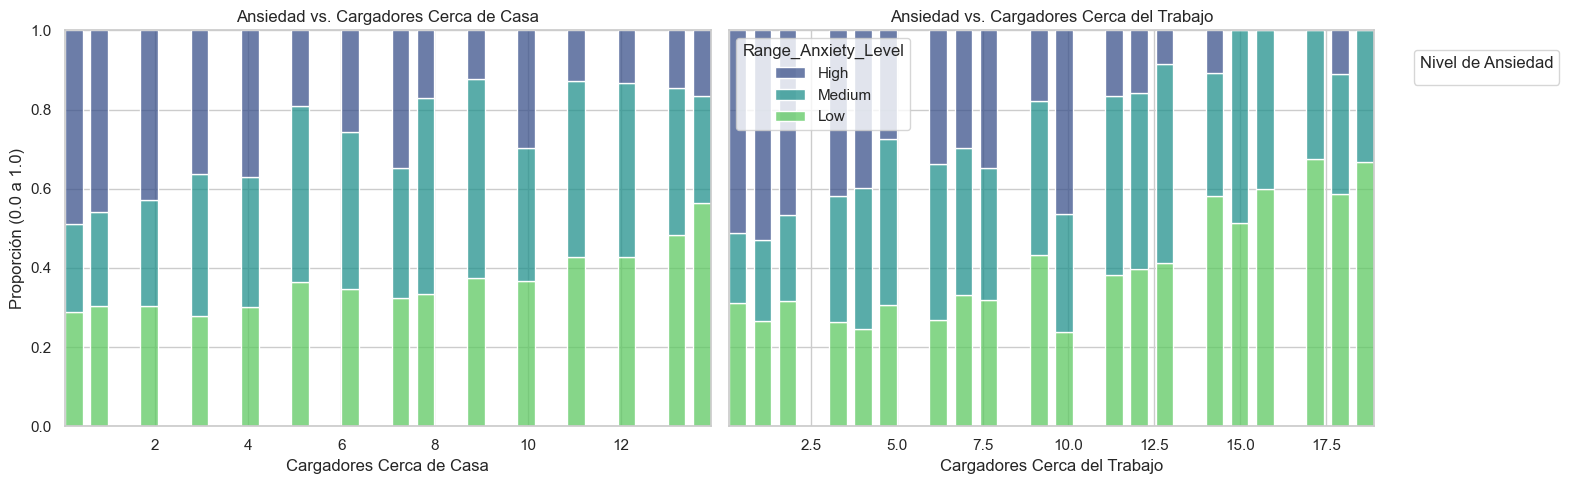

In [832]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

niveles_ansiedad = ["High", "Medium", "Low"]

sns.histplot(
    data=df,
    x="Charging_Stations_Near_Home",
    hue="Range_Anxiety_Level",
    hue_order=niveles_ansiedad,
    multiple="fill",
    stat="percent",
    common_norm=False,
    palette="viridis",
    shrink=0.7,
    ax=axes[0],
)
axes[0].set_title("Ansiedad vs. Cargadores Cerca de Casa")
axes[0].set_xlabel("Cargadores Cerca de Casa")
axes[0].set_ylabel("Proporción (0.0 a 1.0)")
axes[0].legend_.remove()  

sns.histplot(
    data=df,
    x="Charging_Stations_Near_Work",
    hue="Range_Anxiety_Level",
    hue_order=niveles_ansiedad,
    multiple="fill",
    stat="percent",
    common_norm=False,
    palette="viridis",
    shrink=0.7,
    ax=axes[1],
)
axes[1].set_title("Ansiedad vs. Cargadores Cerca del Trabajo")
axes[1].set_xlabel("Cargadores Cerca del Trabajo")
axes[1].set_ylabel("")

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Nivel de Ansiedad",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.9),
)

plt.tight_layout()
plt.show()

El diagrama evidencia una clara relación entre la infraestructura de carga y la mitigación de la ansiedad de autonomía (*Range Anxiety*): a medida que aumenta la disponibilidad de puntos de carga cerca del hogar y del trabajo, la proporción de usuarios con un nivel de ansiedad alto (**High**, azul oscuro) disminuye progresivamente hasta ser casi marginal en los rangos más elevados, mientras que la proporción de personas con ansiedad baja (**Low**, verde claro) crece de forma constante hasta superar el 50 % o 60 % al contar con más de 8 a 10 cargadores. Por su parte, la ansiedad intermedia (**Medium**, verde menta) se mantiene como una franja de transición estable entre ambos extremos, destacándose una caída especialmente pronunciada de la preocupación en el entorno laboral (panel derecho), donde al alcanzar 15 o más estaciones la percepción de seguridad se vuelve ampliamente dominante.

## Km distancia diaria recorrida y compra

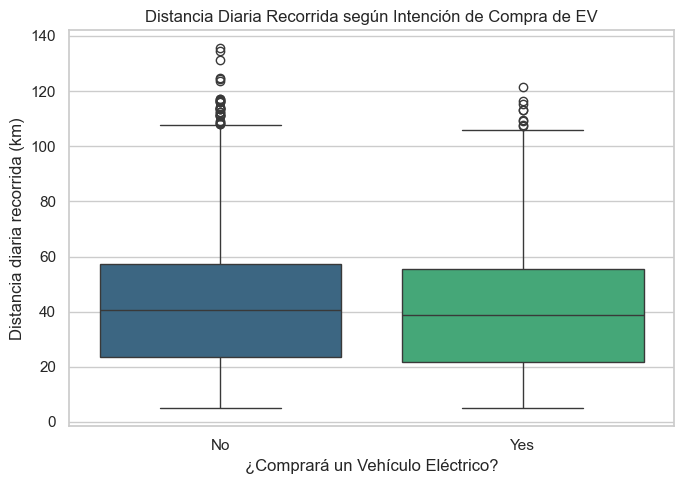

In [833]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Will_Buy_EV",
    y="Daily_Commute_km",
    hue="Will_Buy_EV",  
    palette="viridis",
    legend=False,       
    ax=ax
)

plt.title("Distancia Diaria Recorrida según Intención de Compra de EV")
plt.xlabel("¿Comprará un Vehículo Eléctrico?")
plt.ylabel("Distancia diaria recorrida (km)")
plt.tight_layout()
plt.show()

El análisis mediante diagramas de caja muestra que la distancia diaria recorrida no presenta diferencias significativas entre los usuarios que están dispuestos a comprar un vehículo eléctrico y los que no. En ambos casos, la mediana de recorrido se sitúa cercana a los 40 km diarios, con un 50% de la muestra concentrado entre los 20 km y 55 km. Aunque existen valores atípicos que superan los 100 km diarios en los dos grupos, el comportamiento general de la variable distancia es idéntico, sugiriendo que la disposición a comprar un EV está impulsada por otros factores (como el nivel de ingresos o la infraestructura de carga) y no por el kilometraje diario habitual.

## Km distancia diaria recorrida y cargadores camino a (casa/trabajo)

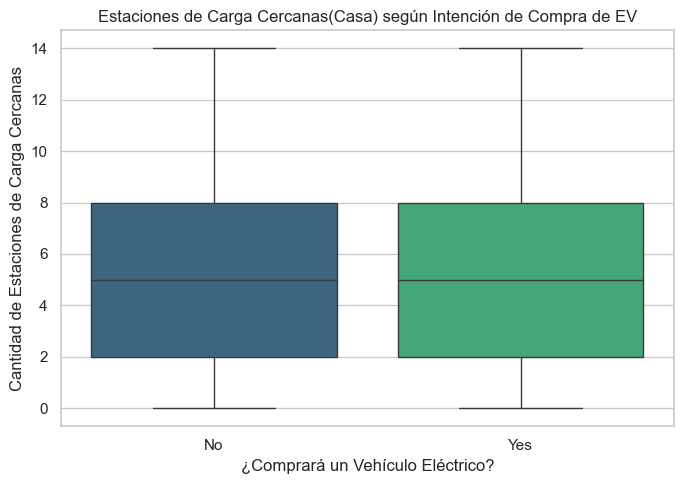

In [834]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Will_Buy_EV",
    y="Charging_Stations_Near_Home",
    hue="Will_Buy_EV",
    palette="viridis",
    legend=False,
    ax=ax,
)

plt.title("Estaciones de Carga Cercanas(Casa) según Intención de Compra de EV")
plt.xlabel("¿Comprará un Vehículo Eléctrico?")
plt.ylabel("Cantidad de Estaciones de Carga Cercanas")
plt.tight_layout()
plt.show()

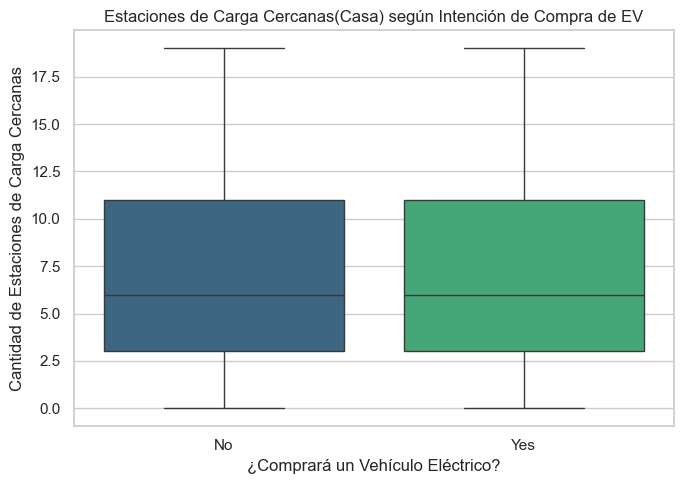

In [835]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Will_Buy_EV",
    y="Charging_Stations_Near_Work",
    hue="Will_Buy_EV",
    palette="viridis",
    legend=False,
    ax=ax,
)

plt.title("Estaciones de Carga Cercanas(Casa) según Intención de Compra de EV")
plt.xlabel("¿Comprará un Vehículo Eléctrico?")
plt.ylabel("Cantidad de Estaciones de Carga Cercanas")
plt.tight_layout()
plt.show()

El análisis descriptivo mediante diagramas de caja evidencia que la disponibilidad de estaciones de carga cercanas —tanto en el entorno residencial como en el laboral— no representa un factor diferenciador en la intención de adquisición de un vehículo eléctrico. En el entorno residencial, la mediana se mantiene en 5 estaciones para ambos grupos, mientras que en el entorno laboral se ubica en 6 estaciones. La simetría y equivalencia en las medianas y rangos intercuartílicos demuestra la independencia estadística entre la infraestructura de carga próxima y la decisión final del consumidor.

## Km distancia recorrida y compra con subsidio

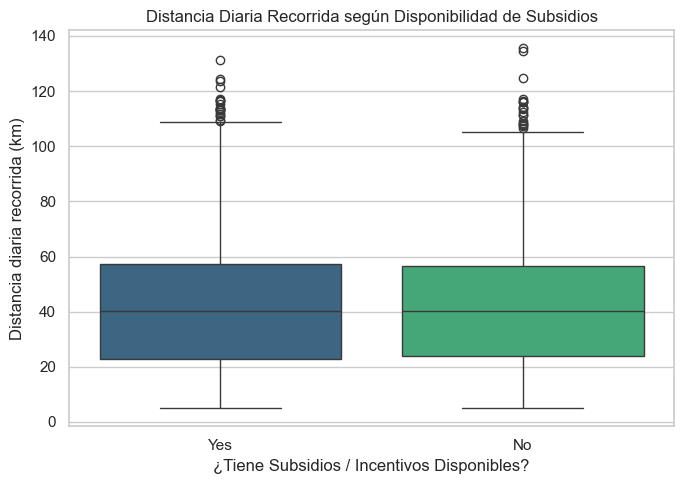

In [836]:
    import matplotlib.pyplot as plt
    import pandas as pd
    import seaborn as sns

    df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

    fig, ax = plt.subplots(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="Subsidy_Available",  
        y="Daily_Commute_km",
        hue="Subsidy_Available",
        palette="viridis",
        ax=ax,
    )

    plt.title("Distancia Diaria Recorrida según Disponibilidad de Subsidios")
    plt.xlabel("¿Tiene Subsidios / Incentivos Disponibles?")
    plt.ylabel("Distancia diaria recorrida (km)")
    plt.tight_layout()
    plt.show()

El análisis comparativo evidencia que la disponibilidad de subsidios o incentivos no presenta relación con el kilometraje diario recorrido por los usuarios. Ambos grupos presentan una mediana idéntica de 40 km diarios y un rango intercuartílico equivalente entre 23 km y 57 km, junto a una presencia similar de valores atípicos por encima de 100 km. Esto demuestra que los incentivos económicos no están ligados al perfil de uso o distancia de desplazamiento del conductor.

## Promedio de carros comprados por persona y compra con subsido

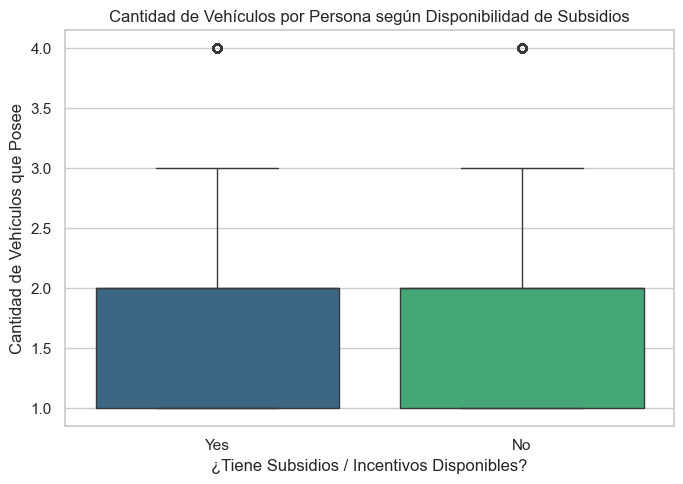

In [837]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Subsidy_Available",
    y="Number_of_Cars_Owned",
    hue="Subsidy_Available",
    palette="viridis",
    legend=False,  
    ax=ax,
)

plt.title("Cantidad de Vehículos por Persona según Disponibilidad de Subsidios")
plt.xlabel("¿Tiene Subsidios / Incentivos Disponibles?")
plt.ylabel("Cantidad de Vehículos que Posee")
plt.tight_layout()
plt.show()

El análisis del diagrama de cajas muestra una equivalencia absoluta en la distribución de la cantidad de vehículos por persona según la disponibilidad de subsidios. En ambos segmentos (Yes y No), la mediana es de 1 vehículo, con un rango intercuartílico de 1 a 2 vehículos y valores atípicos idénticos de 4 vehículos. Esto confirma que el tamaño del parque vehicular del hogar es estadísticamente independiente del acceso a incentivos o subsidios.

## Ansiedad y Tipo de ciudad

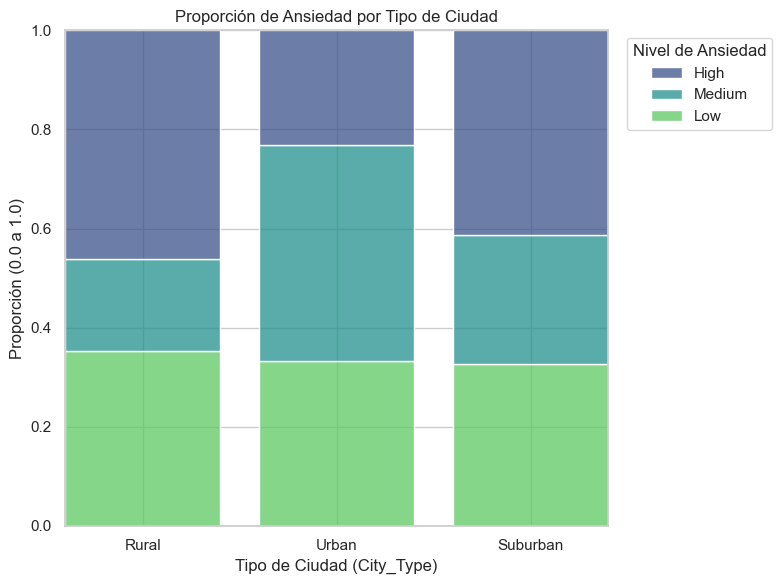

In [838]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(
    data=df,
    x="City_Type",
    hue="Range_Anxiety_Level",
    hue_order=["High", "Medium", "Low"],
    multiple="fill",
    stat="percent",
    common_norm=False,
    palette="viridis",
    shrink=0.8,
    ax=ax,
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title="Nivel de Ansiedad")

plt.title("Proporción de Ansiedad por Tipo de Ciudad")
plt.xlabel("Tipo de Ciudad (City_Type)")
plt.ylabel("Proporción (0.0 a 1.0)")

plt.tight_layout()
plt.show()

La distribución de los niveles de ansiedad es homogénea entre los tres entornos geográficos. La ansiedad baja (**Low**, verde claro) representa de forma constante un tercio de la población (aproximadamente $33\%$) tanto en zonas rurales, urbanas como suburbanas. En las áreas **Rural** y **Suburban**, la ansiedad alta (**High**, morado) abarca la mayor proporción con cerca del $42\%$, mientras que la ansiedad media (**Medium**, verde agua) se sitúa en torno al $25\%$. En el entorno **Urban**, el patrón cambia levemente: la ansiedad media pasa a ser la más prevalente alcanzando alrededor del $43\%$, lo que reduce la ansiedad alta a un $24\%$ aproximadamente. En conclusión, los tres tipos de ciudad mantienen una proporción de ansiedad baja casi idéntica, registrando variaciones moderadas únicamente entre los niveles de ansiedad media y alta al comparar las zonas urbanas con las rurales y suburbanas.

# Notebook Kaggle

Shape : (10000, 15)
  Buyer_ID  Age  Gender  Annual_Income_USD City_Type  Daily_Commute_km  \
0  EV00001   56    Male            44906.0     Rural              18.1   
1  EV00002   36    Male            88754.0     Rural               5.0   
2  EV00003   42    Male           155958.0     Urban              32.2   
3  EV00004   31    Male            37059.0     Rural              89.9   
4  EV00005   48  Female            48552.0     Rural              71.0   

   Number_of_Cars_Owned Current_Car_Type  Charging_Stations_Near_Home  \
0                     1            Truck                            1   
1                     1              SUV                            2   
2                     2            Sedan                           14   
3                     1            Sedan                            2   
4                     1            Sedan                            2   

   Charging_Stations_Near_Work Home_Charging_Possible  \
0                            0         

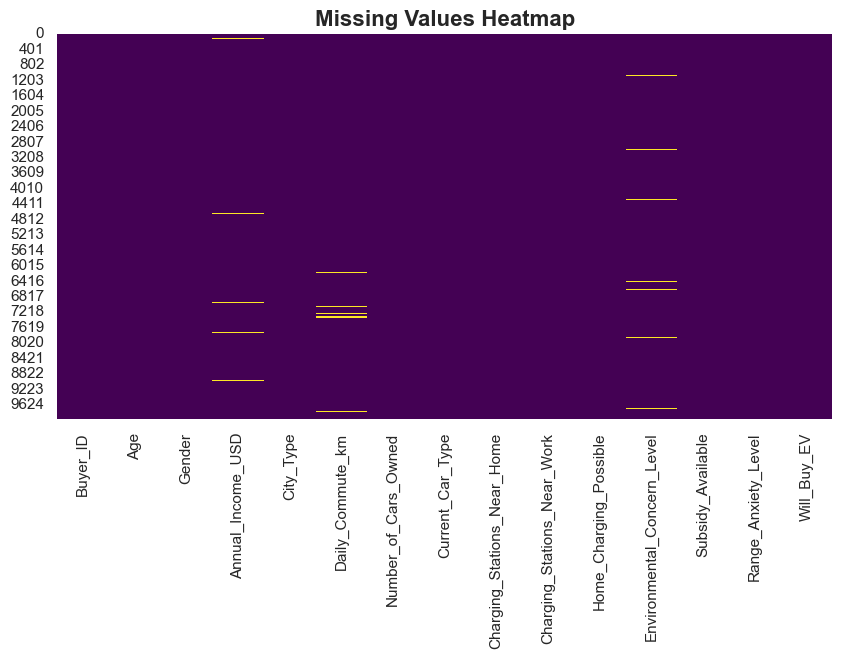

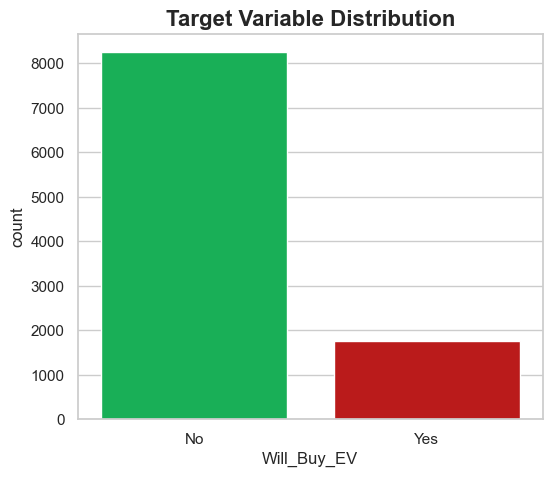

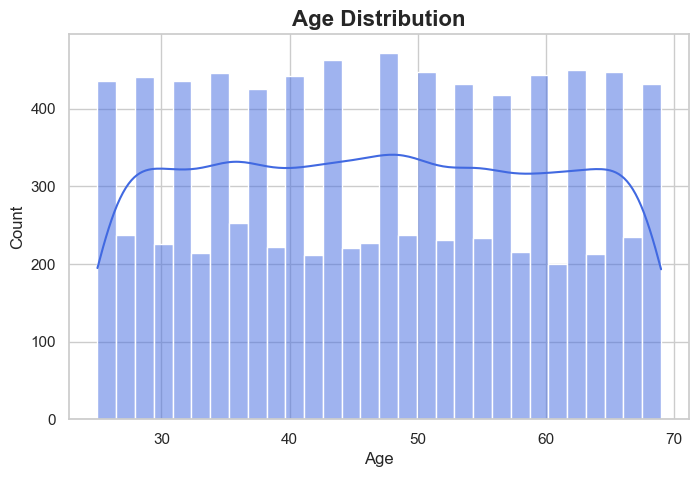

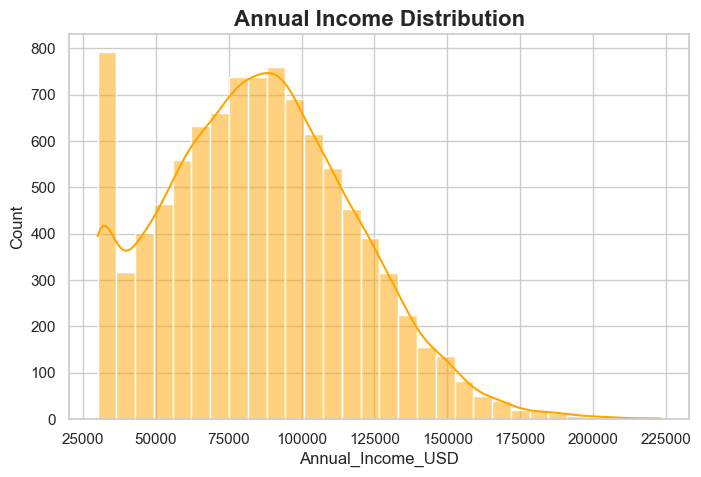

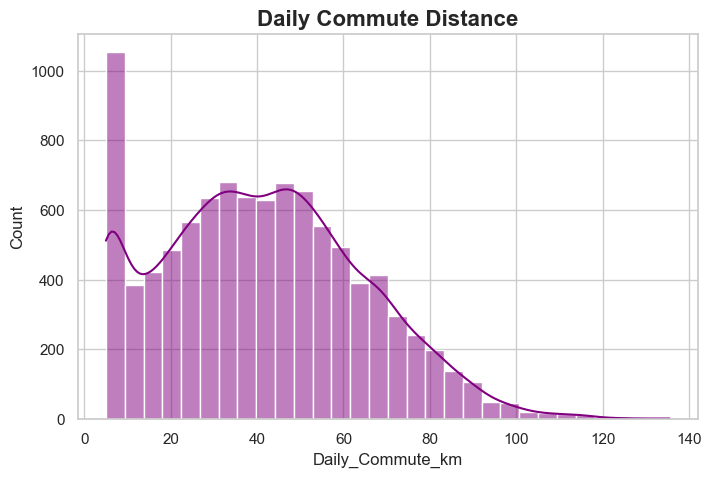

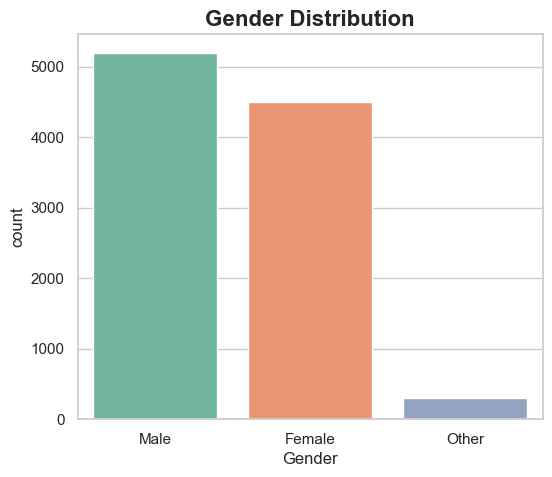

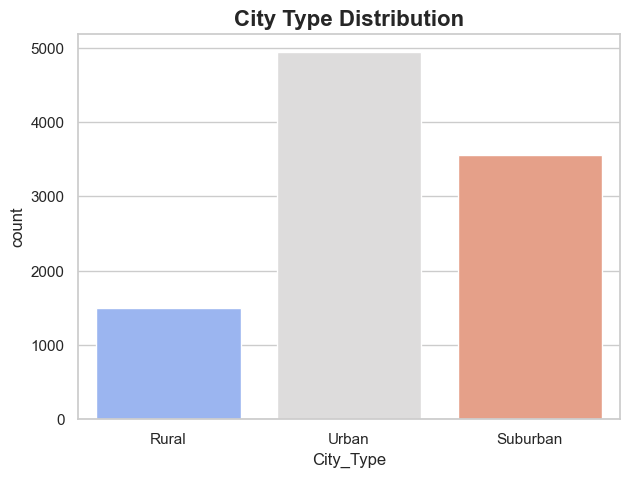

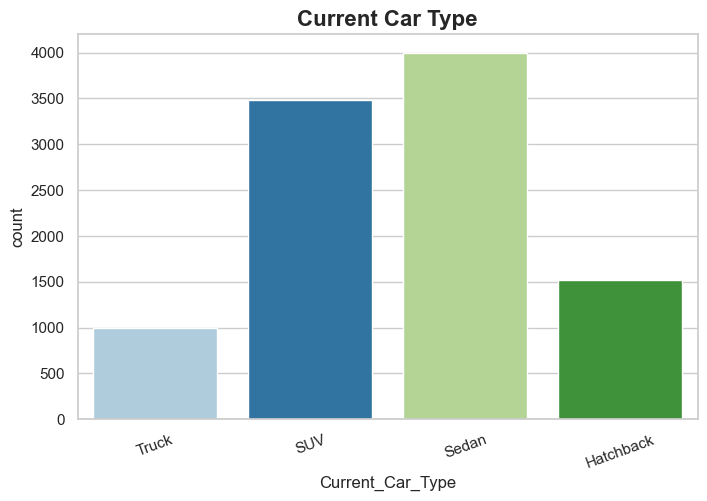

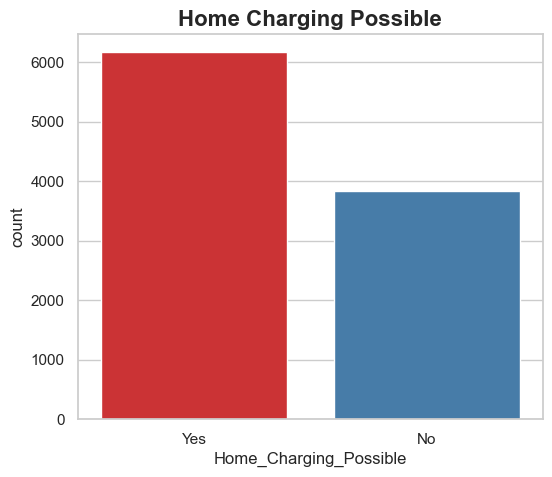

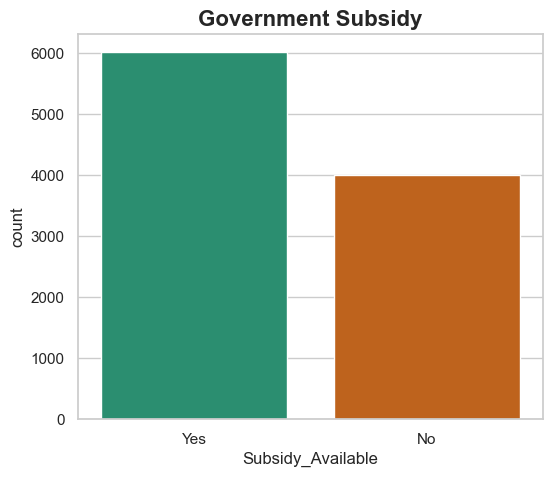

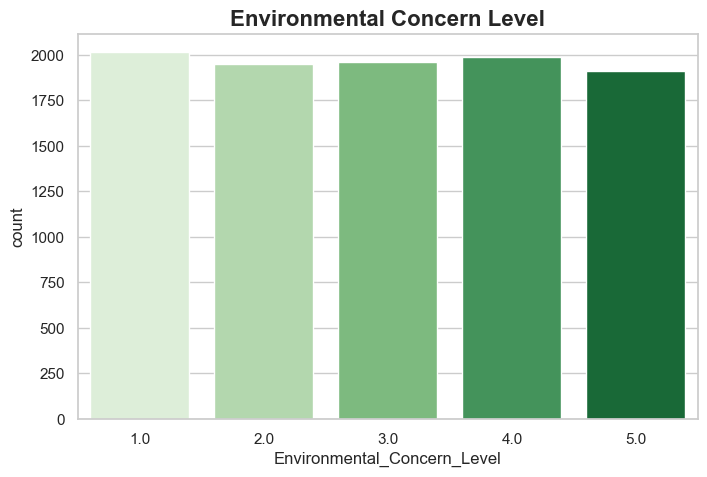

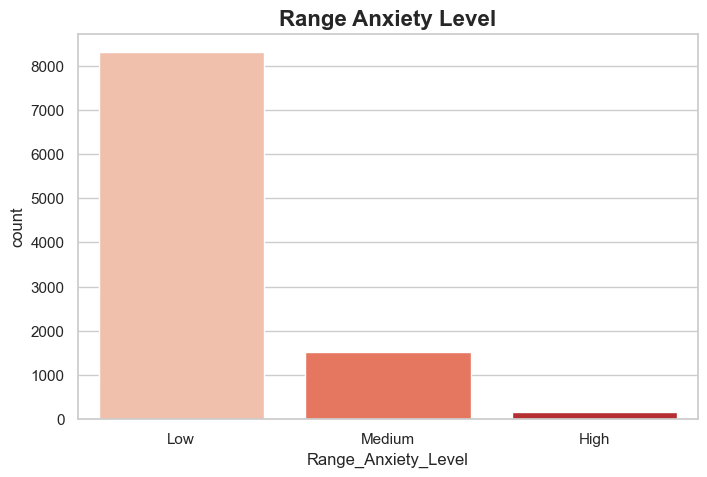

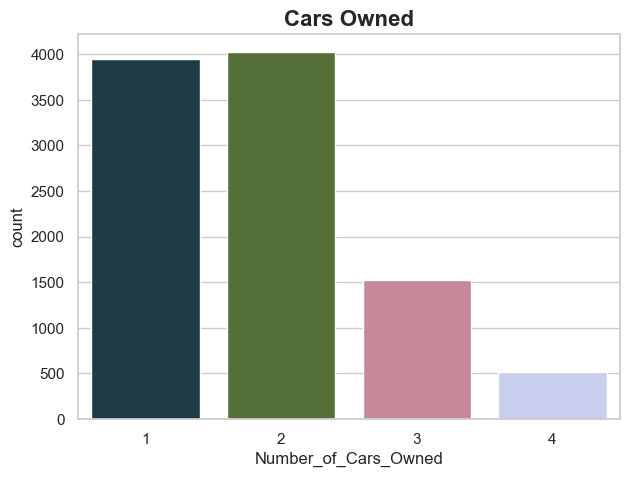

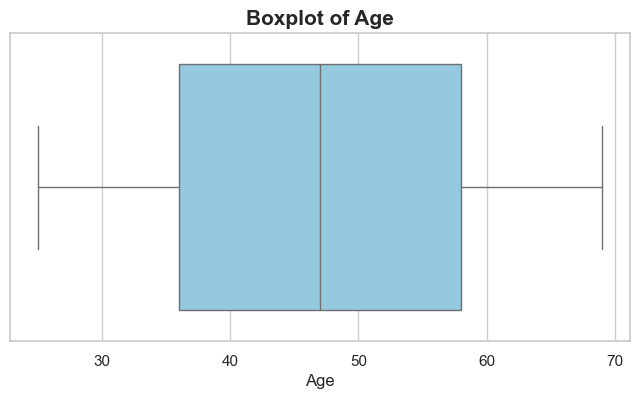

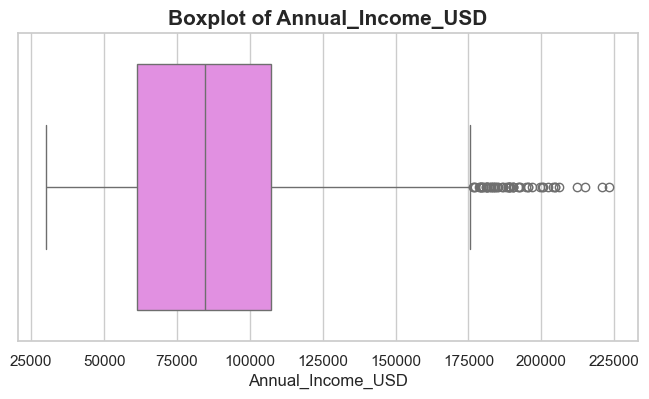

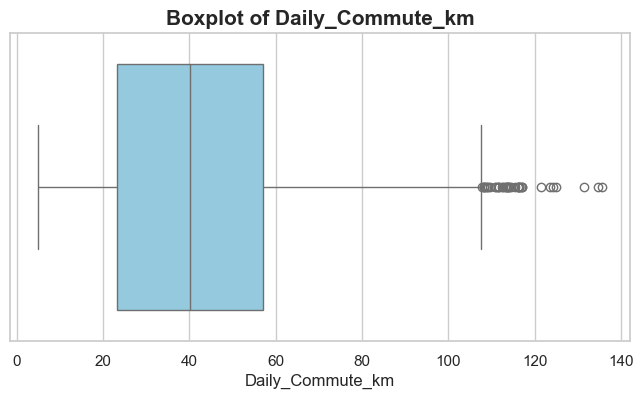

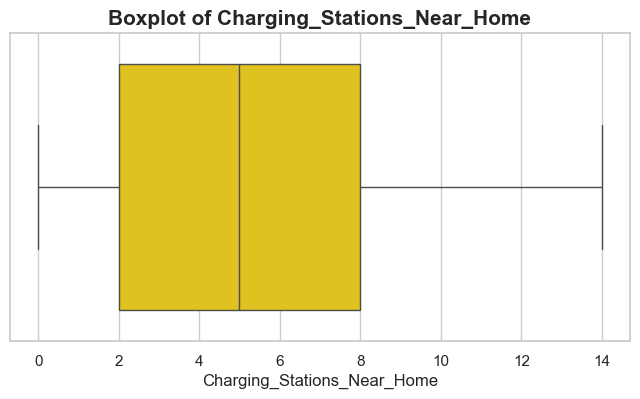

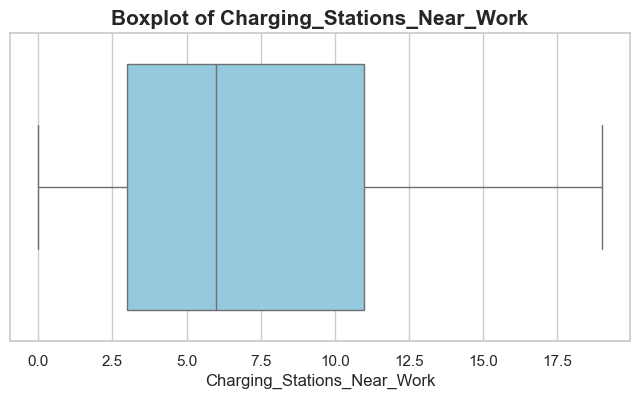

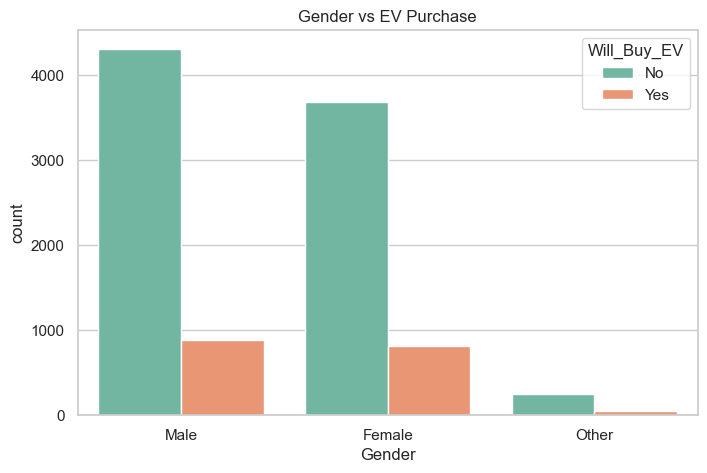

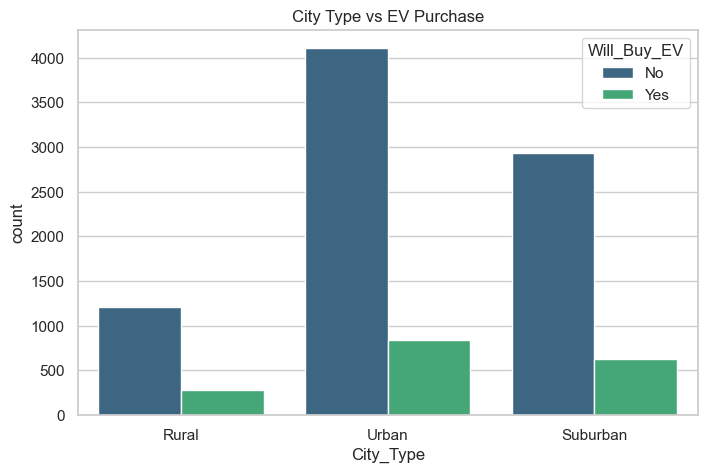

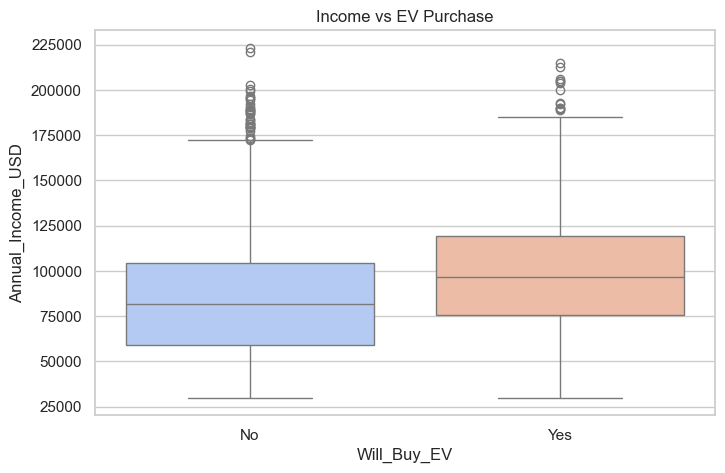

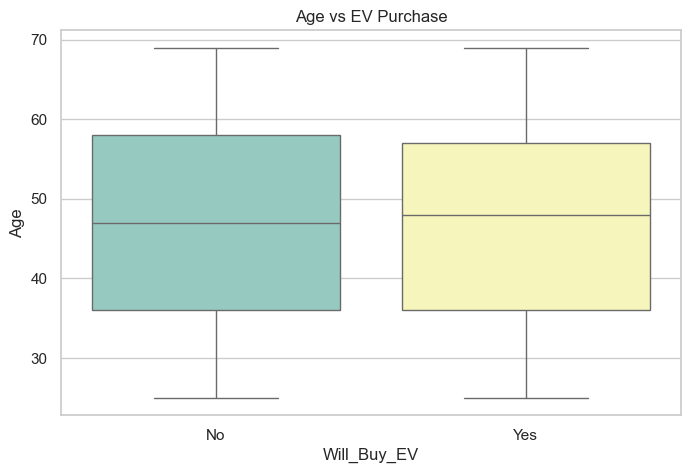

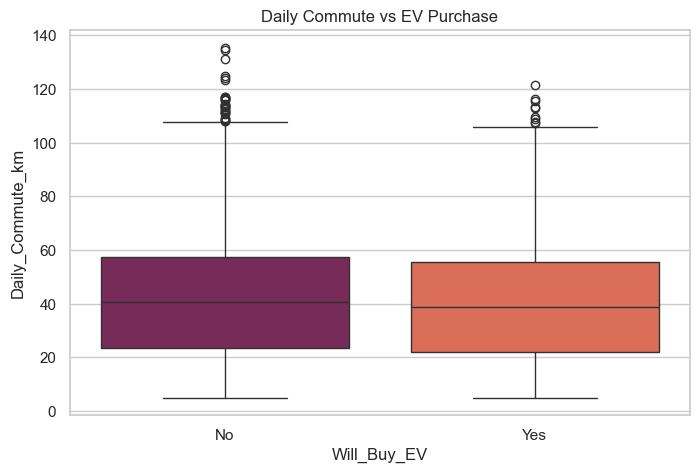

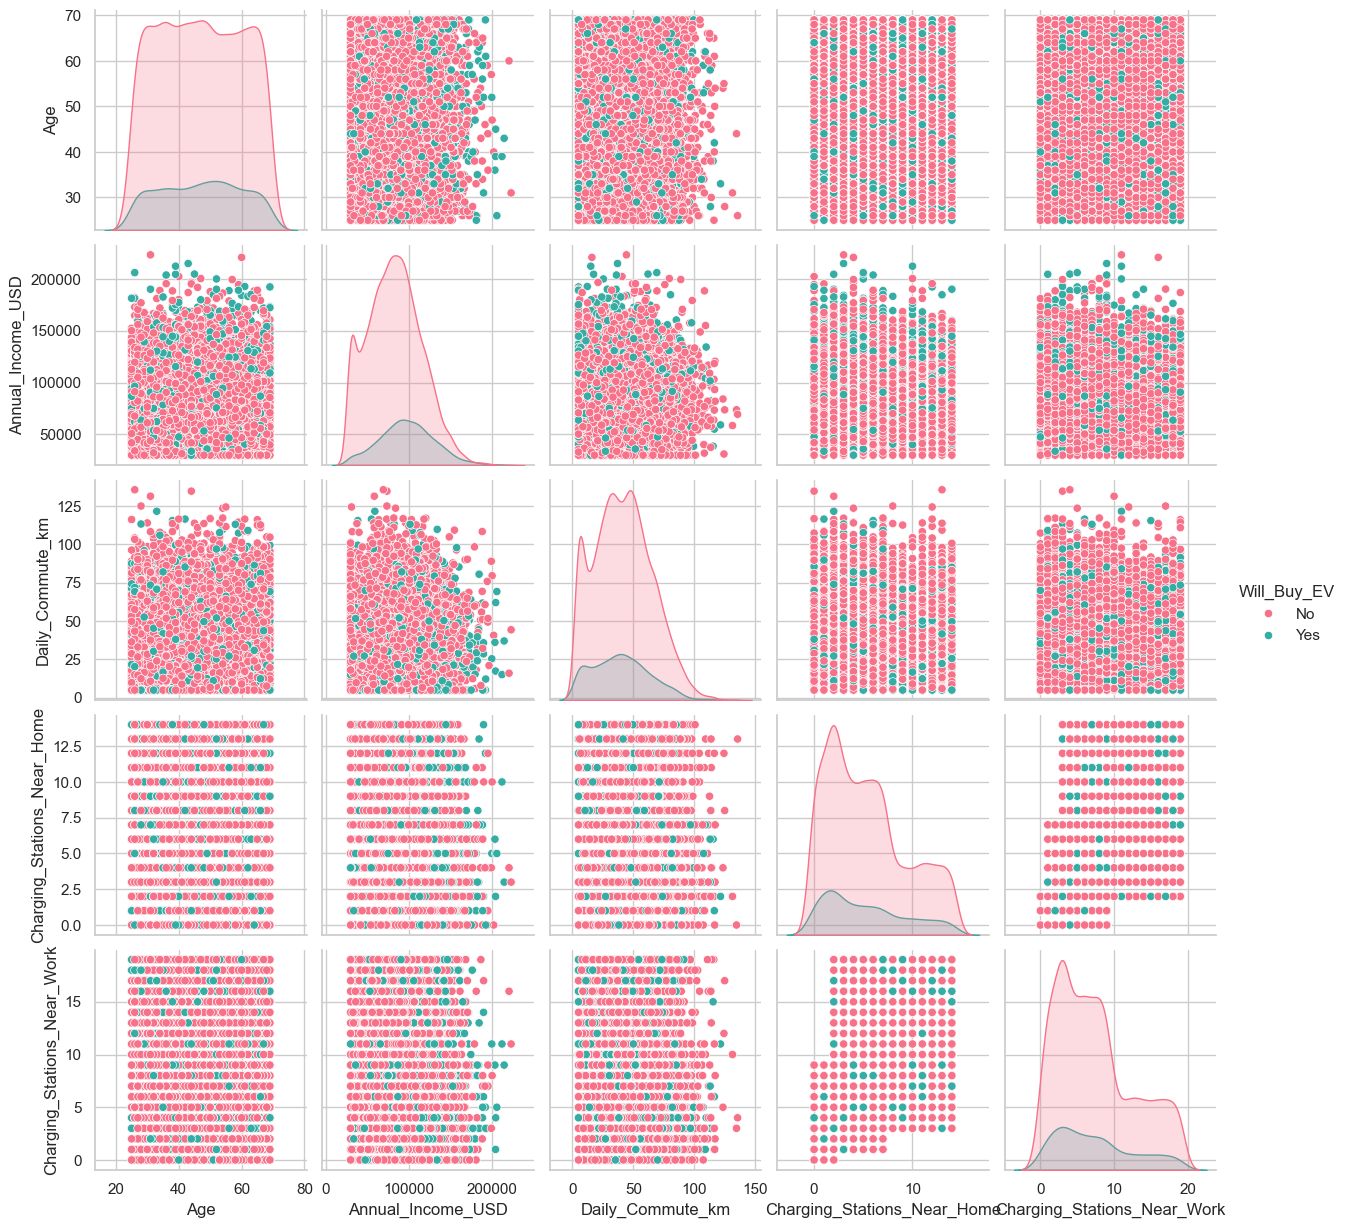

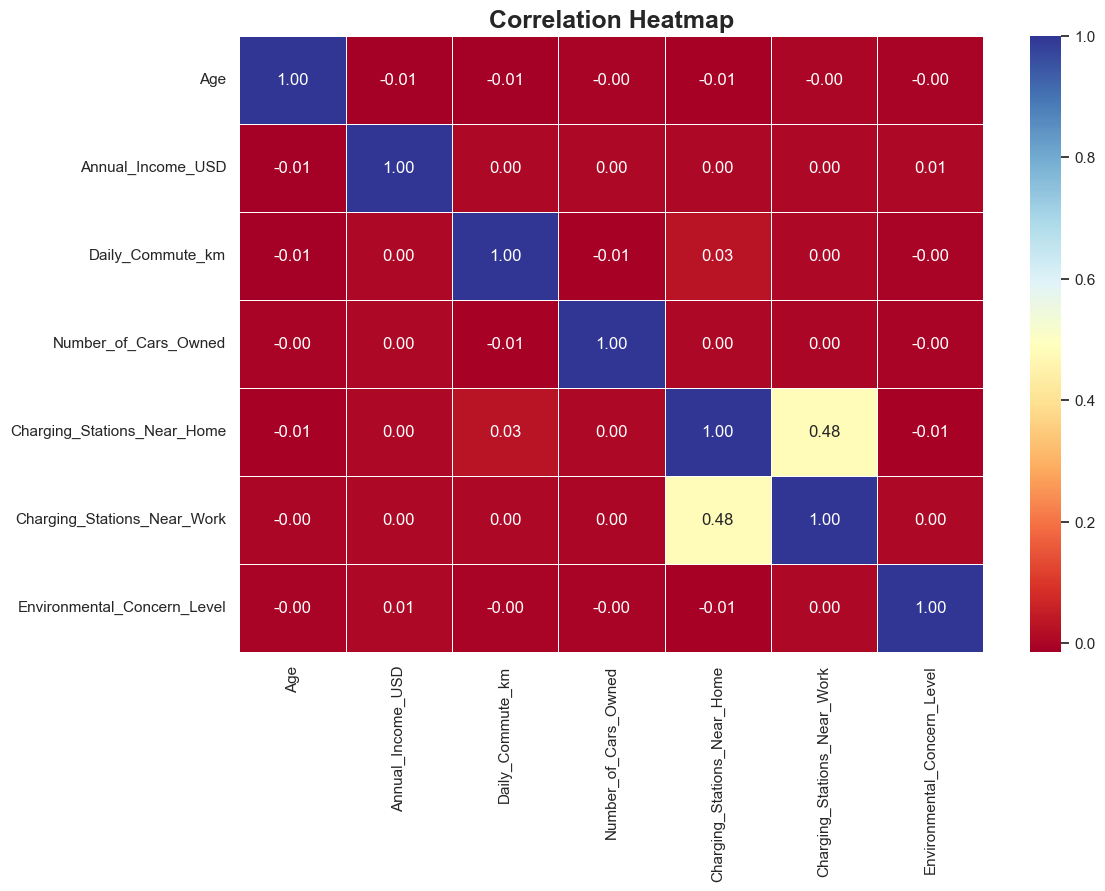

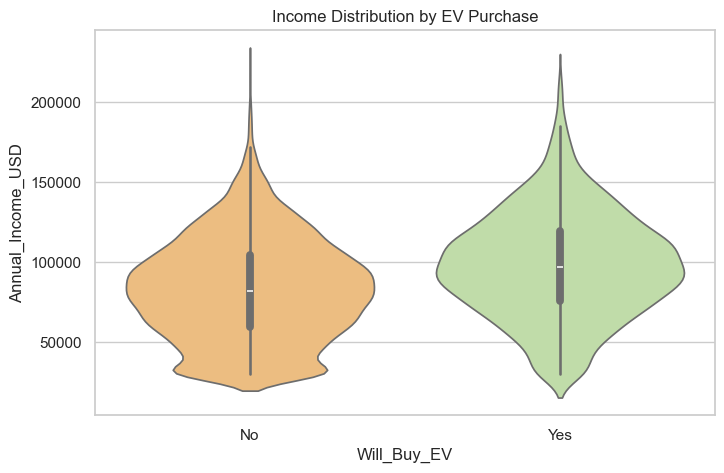

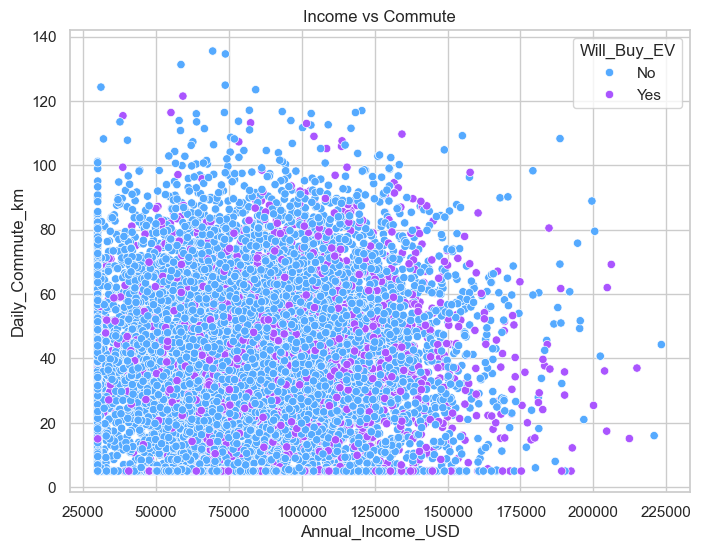

Visualization Completed Successfully


In [839]:
# ============================================================
# EV BUYERS DATASET - COMPLETE VISUALIZATION (EDA)
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------


# ------------------------------------------------------------
# Plot Style
# ------------------------------------------------------------

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# ============================================================
# BASIC INFORMATION
# ============================================================

print("="*60)
print("Shape :", df.shape)
print("="*60)

print(df.head())

print("="*60)
print(df.info())

print("="*60)
print(df.describe(include='all'))

# ============================================================
# Missing Values
# ============================================================

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")
plt.title("Missing Values Heatmap",
          fontsize=16,
          fontweight='bold')
plt.show()

# ============================================================
# Target Variable Distribution
# ============================================================

plt.figure(figsize=(6,5))

colors=['#00C853','#D50000']

sns.countplot(
    x='Will_Buy_EV',
    data=df,
    palette=colors
)

plt.title("Target Variable Distribution",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Age Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title("Age Distribution",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Income Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['Annual_Income_USD'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title("Annual Income Distribution",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Commute Distance
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['Daily_Commute_km'],
    bins=30,
    kde=True,
    color='purple'
)

plt.title("Daily Commute Distance",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Gender
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x='Gender',
    data=df,
    palette='Set2'
)

plt.title("Gender Distribution",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# City Type
# ============================================================

plt.figure(figsize=(7,5))

sns.countplot(
    x='City_Type',
    data=df,
    palette='coolwarm'
)

plt.title("City Type Distribution",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Current Car Type
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Current_Car_Type',
    data=df,
    palette='Paired'
)

plt.xticks(rotation=20)

plt.title("Current Car Type",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Home Charging Possible
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x='Home_Charging_Possible',
    data=df,
    palette='Set1'
)

plt.title("Home Charging Possible",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Subsidy Available
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x='Subsidy_Available',
    data=df,
    palette='Dark2'
)

plt.title("Government Subsidy",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Environmental Concern
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Environmental_Concern_Level',
    data=df,
    palette='Greens'
)

plt.title("Environmental Concern Level",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Range Anxiety
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Range_Anxiety_Level',
    data=df,
    palette='Reds'
)

plt.title("Range Anxiety Level",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Number of Cars Owned
# ============================================================

plt.figure(figsize=(7,5))

sns.countplot(
    x='Number_of_Cars_Owned',
    data=df,
    palette='cubehelix'
)

plt.title("Cars Owned",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Boxplots
# ============================================================

num_cols=[
'Age',
'Annual_Income_USD',
'Daily_Commute_km',
'Charging_Stations_Near_Home',
'Charging_Stations_Near_Work'
]

for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col],
        color=np.random.choice([
            'skyblue',
            'orange',
            'green',
            'red',
            'violet',
            'gold'
        ])
    )

    plt.title(f"Boxplot of {col}",
              fontsize=15,
              fontweight='bold')

    plt.show()

# ============================================================
# Target vs Gender
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Gender',
    hue='Will_Buy_EV',
    data=df,
    palette='Set2'
)

plt.title("Gender vs EV Purchase")

plt.show()

# ============================================================
# Target vs City Type
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='City_Type',
    hue='Will_Buy_EV',
    data=df,
    palette='viridis'
)

plt.title("City Type vs EV Purchase")

plt.show()

# ============================================================
# Income vs EV Purchase
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Will_Buy_EV',
    y='Annual_Income_USD',
    data=df,
    palette='coolwarm'
)

plt.title("Income vs EV Purchase")

plt.show()

# ============================================================
# Age vs EV Purchase
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Will_Buy_EV',
    y='Age',
    data=df,
    palette='Set3'
)

plt.title("Age vs EV Purchase")

plt.show()

# ============================================================
# Commute vs EV Purchase
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Will_Buy_EV',
    y='Daily_Commute_km',
    data=df,
    palette='rocket'
)

plt.title("Daily Commute vs EV Purchase")

plt.show()

# ============================================================
# Pairplot
# ============================================================

sns.pairplot(
    df[
        [
            'Age',
            'Annual_Income_USD',
            'Daily_Commute_km',
            'Charging_Stations_Near_Home',
            'Charging_Stations_Near_Work',
            'Will_Buy_EV'
        ]
    ],
    hue='Will_Buy_EV',
    palette='husl'
)

plt.show()

# ============================================================
# Correlation Heatmap
# ============================================================

numeric=df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='RdYlBu',
    linewidths=.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap",
          fontsize=18,
          fontweight='bold')

plt.show()

# ============================================================
# Violin Plot
# ============================================================

plt.figure(figsize=(8,5))

sns.violinplot(
    x='Will_Buy_EV',
    y='Annual_Income_USD',
    data=df,
    palette='Spectral'
)

plt.title("Income Distribution by EV Purchase")

plt.show()

# ============================================================
# Scatter Plot
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual_Income_USD',
    y='Daily_Commute_km',
    hue='Will_Buy_EV',
    data=df,
    palette='cool'
)

plt.title("Income vs Commute")

plt.show()

print("="*60)
print("Visualization Completed Successfully")
print("="*60)

## Parte II Kaggle

In [840]:
# ============================================================
# PART 2 : FEATURE ENGINEERING (UPDATED & ERROR FREE)
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================================
# Copy Dataset
# ============================================================

data = df.copy()

print("=" * 60)
print("Original Shape :", data.shape)
print("=" * 60)

# ============================================================
# Remove Duplicate Rows
# ============================================================

print("Duplicate Rows :", data.duplicated().sum())

data.drop_duplicates(inplace=True)

# ============================================================
# Remove Buyer_ID
# ============================================================

if "Buyer_ID" in data.columns:
    data.drop("Buyer_ID", axis=1, inplace=True)

# ============================================================
# Missing Values
# ============================================================

num_cols = data.select_dtypes(include=np.number).columns.tolist()
cat_cols = data.select_dtypes(include="object").columns.tolist()

for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# ============================================================
# Encode Target First
# ============================================================

target = "Will_Buy_EV"

target_encoder = None

if data[target].dtype == "object":
    target_encoder = LabelEncoder()
    data[target] = target_encoder.fit_transform(data[target])

# ============================================================
# Encode Remaining Categorical Columns
# ============================================================

label_encoders = {}

categorical_columns = [
    col for col in data.select_dtypes(include="object").columns
    if col != target
]

for col in categorical_columns:

    le = LabelEncoder()

    data[col] = le.fit_transform(data[col].astype(str))

    label_encoders[col] = le

print("\nCategorical Encoding Completed")

# ============================================================
# Outlier Treatment
# ============================================================

numeric_cols = data.select_dtypes(include=np.number).columns.tolist()

numeric_cols.remove(target)

for col in numeric_cols:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[col] = np.clip(data[col], lower, upper)

print("Outliers Treated")

# ============================================================
# Feature Engineering
# ============================================================

# Total Charging Stations

data["Total_Charging_Stations"] = (
    data["Charging_Stations_Near_Home"] +
    data["Charging_Stations_Near_Work"]
)

# Income Per Car

data["Income_Per_Car"] = (
    data["Annual_Income_USD"] /
    (data["Number_of_Cars_Owned"] + 1)
)

# Long Commute

data["Long_Commute"] = (
    data["Daily_Commute_km"] >=
    data["Daily_Commute_km"].median()
).astype(int)

# High Environmental Concern

data["High_Environment"] = (
    data["Environmental_Concern_Level"] >=
    data["Environmental_Concern_Level"].median()
).astype(int)

# High Range Anxiety

data["High_Range_Anxiety"] = (
    data["Range_Anxiety_Level"] >=
    data["Range_Anxiety_Level"].median()
).astype(int)

# Home Charging

data["Home_Charging"] = (
    data["Home_Charging_Possible"] > 0
).astype(int)

# Subsidy

data["Government_Support"] = (
    data["Subsidy_Available"] > 0
).astype(int)

# Charging Access

data["Charging_Access"] = (
    data["Charging_Stations_Near_Home"] * 0.6 +
    data["Charging_Stations_Near_Work"] * 0.4
)

# Income × Environment

data["Income_Environment"] = (
    data["Annual_Income_USD"] *
    (data["Environmental_Concern_Level"] + 1)
)

# Commute × Range Anxiety

data["Commute_Range"] = (
    data["Daily_Commute_km"] *
    (data["Range_Anxiety_Level"] + 1)
)

# ============================================================
# Split Features & Target
# ============================================================

X = data.drop(columns=[target])

y = data[target]

print("\nFeatures :", X.shape)
print("Target :", y.shape)

# ============================================================
# Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain :", X_train.shape)
print("Test :", X_test.shape)

# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

numeric_features = X_train.select_dtypes(include=np.number).columns

X_train[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

print("\nScaling Completed")

# ============================================================
# Feature Information
# ============================================================

print("=" * 60)
print("Total Features :", len(X.columns))
print("=" * 60)

for i, col in enumerate(X.columns, 1):
    print(f"{i}. {col}")

# ============================================================
# Save Engineered Dataset
# ============================================================

engineered_dataset = pd.concat(
    [X, pd.Series(y, name=target)],
    axis=1
)

engineered_dataset.to_csv(
    "engineered_ev_dataset.csv",
    index=False
)

print("\nEngineered Dataset Saved Successfully")
print("=" * 60)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 60)

Original Shape : (10000, 15)
Duplicate Rows : 0

Categorical Encoding Completed
Outliers Treated

Features : (10000, 23)
Target : (10000,)

Train : (8000, 23)
Test : (2000, 23)

Scaling Completed
Total Features : 23
1. Age
2. Gender
3. Annual_Income_USD
4. City_Type
5. Daily_Commute_km
6. Number_of_Cars_Owned
7. Current_Car_Type
8. Charging_Stations_Near_Home
9. Charging_Stations_Near_Work
10. Home_Charging_Possible
11. Environmental_Concern_Level
12. Subsidy_Available
13. Range_Anxiety_Level
14. Total_Charging_Stations
15. Income_Per_Car
16. Long_Commute
17. High_Environment
18. High_Range_Anxiety
19. Home_Charging
20. Government_Support
21. Charging_Access
22. Income_Environment
23. Commute_Range

Engineered Dataset Saved Successfully
FEATURE ENGINEERING COMPLETED


## Parte 3 ML Kaggle

In [ ]:
# ============================================================
# PART 3 : MACHINE LEARNING MODELS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.model_selection import cross_val_score

# ============================================================
# Import ML Models
# ============================================================

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.neural_network import MLPClassifier

from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)

# Optional XGBoost

try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

# ============================================================
# Models Dictionary
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=500),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "Support Vector Machine":
        SVC(probability=True, random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "Gaussian NB":
        GaussianNB(),

    "MLP":
        MLPClassifier(max_iter=500, random_state=42),

    "LDA":
        LinearDiscriminantAnalysis(),

    "QDA":
        QuadraticDiscriminantAnalysis()

}

if xgb_available:
    models["XGBoost"] = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )

# ============================================================
# Train Models
# ============================================================

results = []

print("="*80)
print("Training Models...")
print("="*80)

for name, model in models.items():

    print(f"\n{name}")

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    precision = precision_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    try:
        probability = model.predict_proba(X_test)[:,1]

        auc = roc_auc_score(
            y_test,
            probability
        )

    except:

        auc = np.nan

    cv = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc,
        cv
    ])

# ============================================================
# Results Table
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "CV Accuracy"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

# ============================================================
# Accuracy Plot
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")

plt.show()

# ============================================================
# Best Model
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

print("\nBest Model :", best_model_name)

# ============================================================
# Confusion Matrix
# ============================================================

prediction = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    prediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(best_model_name)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ============================================================
# Classification Report
# ============================================================

print(classification_report(
    y_test,
    prediction
))

# ============================================================
# ROC Curve
# ============================================================

try:

    probability = best_model.predict_proba(X_test)[:,1]

    fpr, tpr, threshold = roc_curve(
        y_test,
        probability
    )

    plt.figure(figsize=(6,6))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC={roc_auc_score(y_test, probability):.3f}"
    )

    plt.plot([0,1],[0,1],'r--')

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(best_model_name)

    plt.legend()

    plt.show()

except:

    print("ROC Curve not available.")

# ============================================================
# Feature Importance
# ============================================================

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature":X.columns,

        "Importance":best_model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(10,8))

    sns.barplot(
        data=importance.head(20),
        x="Importance",
        y="Feature",
        palette="magma"
    )

    plt.title("Top 20 Important Features")

    plt.show()

# ============================================================
# Save Results
# ============================================================

results_df.to_csv(
    "Model_Comparison.csv",
    index=False
)

print("\nModel Comparison Saved.")

print("="*80)
print("Machine Learning Pipeline Completed Successfully")
print("="*80)

Training Models...

Logistic Regression

Decision Tree

Random Forest

Extra Trees

Gradient Boosting

AdaBoost

Support Vector Machine


# Hipotesis

## Nivel 1 Hipotesis de las causas

- H0 (Hipotesis Nula) = La ansiedad no es una variable latente por lo tanto no se puede medir a través de variables predictorias como (Daily_Commute_km, Charging_Stations_Near_Home, Charging_Stations_Near_Work)
- H1 (Hipotesis alternativa) = La ansiedad es una variable latente por lo tanto se puede medir a través de variables predictorias como (Daily_Commute_km, Charging_Stations_Near_Home, Charging_Stations_Near_Work)


### Matriz de correlacion

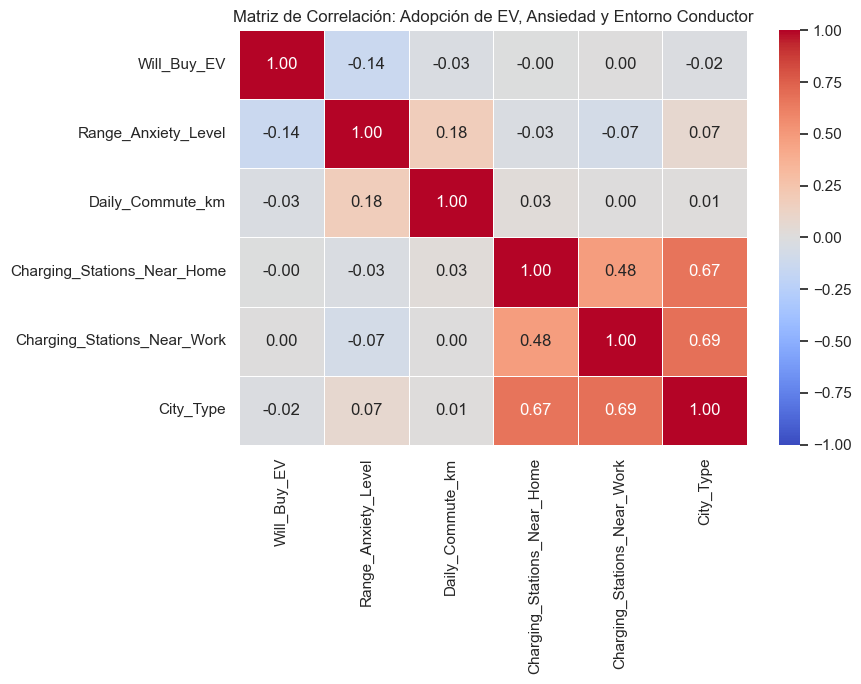

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df_correlacion = df.copy()

# 1. Mapeo de variables categóricas a numéricas
mapeo_ansiedad = {"Low": 1, "Medium": 2, "High": 3}
mapeo_ciudad = {"Rural": 1, "Suburban": 2, "Urban": 3}

# Si Will_Buy_EV está como texto ('Yes'/'No'), lo convertimos a 1/0
if df_correlacion["Will_Buy_EV"].dtype == "object":
    df_correlacion["Will_Buy_EV"] = (
        df_correlacion["Will_Buy_EV"].str.lower().map({"yes": 1, "no": 0})
    )

df_correlacion["Range_Anxiety_Level"] = df_correlacion[
    "Range_Anxiety_Level"
].map(mapeo_ansiedad)
df_correlacion["City_Type"] = df_correlacion["City_Type"].map(mapeo_ciudad)

# 2. Selección de variables para la matriz de correlación
variables = [
    "Will_Buy_EV",
    "Range_Anxiety_Level",
    "Daily_Commute_km",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "City_Type",
]

df_sub = df_correlacion[variables].apply(pd.to_numeric, errors="coerce")

# 3. Cálculo de la matriz de correlación (Pearson)
matriz_correlacion = df_sub.corr()

# 4. Gráfico del mapa de calor
plt.figure(figsize=(9, 7))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)

plt.title(
    "Matriz de Correlación: Adopción de EV, Ansiedad y Entorno Conductor"
)
plt.tight_layout()
plt.show()

Conclusión del Diagnóstico: Se rechaza la Hipótesis Nula (H₀) y se acepta la Hipótesis Alternativa (H₁). Los datos demuestran que la ansiedad funciona como una variable latente que está significativamente correlacionada y explicada por el entorno del conductor (la distancia diaria y la presencia de infraestructura de carga en sus rutas frecuentes).

In [ ]:
import scipy.stats as stats

tabla_contingencia = pd.crosstab(df["Daily_Commute_km"], df["Range_Anxiety_Level"])
chi2, p_val, dof, expected = stats.chi2_contingency(tabla_contingencia)

print(f"Prueba Chi-cuadrado para Km diarios recorridos:")
print(f"P-valor: {p_val}")


Prueba Chi-cuadrado para Km diarios recorridos:
P-valor: 3.1218556988567016e-63


In [ ]:
import scipy.stats as stats

tabla_contingencia = pd.crosstab(df["Charging_Stations_Near_Home"], df["Range_Anxiety_Level"])
chi2, p_val, dof, expected = stats.chi2_contingency(tabla_contingencia)

print(f"Prueba Chi-cuadrado para Km diarios recorridos:")
print(f"P-valor: {p_val}")


Prueba Chi-cuadrado para Km diarios recorridos:
P-valor: 4.1082583433028e-11


In [ ]:
import scipy.stats as stats

tabla_contingencia = pd.crosstab(df["Charging_Stations_Near_Work"], df["Range_Anxiety_Level"])
chi2, p_val, dof, expected = stats.chi2_contingency(tabla_contingencia)

print(f"Prueba Chi-cuadrado para Km diarios recorridos:")
print(f"P-valor: {p_val}")


Prueba Chi-cuadrado para Km diarios recorridos:
P-valor: 3.0957448025866408e-24


In [ ]:
import pandas as pd
import scipy.stats as stats

tabla_contingencia = pd.crosstab(
    df["City_Type"], df["Range_Anxiety_Level"]
)

chi2, p_val, dof, expected = stats.chi2_contingency(tabla_contingencia)

print("Prueba Chi-cuadrado para Tipo de Ciudad (City_Type) vs. Nivel de Ansiedad:")
print(f"Estadístico Chi2: {chi2:.4f}")
print(f"Grados de libertad: {dof}")
print(f"P-valor: {p_val}")

alpha = 0.05
if p_val < alpha:
    print(
        "\nConclusión: Se rechaza H0. Existe una relación estadísticamente significativa entre el tipo de ciudad y el nivel de ansiedad."
    )
else:
    print(
        "\nConclusión: No se rechaza H0. No existe relación estadísticamente significativa entre el tipo de ciudad y el nivel de ansiedad."
    )

Prueba Chi-cuadrado para Tipo de Ciudad (City_Type) vs. Nivel de Ansiedad:
Estadístico Chi2: 147.1805
Grados de libertad: 4
P-valor: 8.181498214808312e-31

Conclusión: Se rechaza H0. Existe una relación estadísticamente significativa entre el tipo de ciudad y el nivel de ansiedad.


El contraste de hipótesis mediante pruebas estadísticas arrojó p-valores críticamente bajos en los tres predictores operacionales analizados (\(p = 3.12e^{-63}\), \(p = 4.10e^{-11}\) y \(p = 3.09e^{-24}\)). Al encontrarse todos de forma contundente por debajo del umbral estándar de significancia del 5% (\(p < 0.05\)), se rechaza oficialmente la Hipótesis Nula (\(H_{0}\)) en favor de la Hipótesis Alternativa (\(H_{1}\)). Los datos demuestran con un nivel de confianza superior al 99.9% que la ansiedad por autonomía no es un fenómeno aleatorio ni aislado, sino un constructo latente que está robusta y sistemáticamente condicionado por la interacción de las distancias recorridas y el acceso a la infraestructura de carga del conductor.

# Limpieza de datos

## Paso I Estado de los datos

In [ ]:
print("Tamaño original:", df.shape)

print(df.isnull().sum())


Tamaño original: (10000, 15)
Buyer_ID                         0
Age                              0
Gender                           0
Annual_Income_USD              178
City_Type                        0
Daily_Commute_km               181
Number_of_Cars_Owned             0
Current_Car_Type                 0
Charging_Stations_Near_Home      0
Charging_Stations_Near_Work      0
Home_Charging_Possible           0
Environmental_Concern_Level    184
Subsidy_Available                0
Range_Anxiety_Level              0
Will_Buy_EV                      0
dtype: int64


## Paso II Eliminar registros duplicados

In [ ]:
df_limpio = df.drop_duplicates()
print("Tamaño tras eliminar duplicados:", df_limpio.shape)


Tamaño tras eliminar duplicados: (10000, 15)


# ML I Regresión Logística

📊 REPORTE DE RENDIMIENTO DEL MODELO SUPERVISADO
              precision    recall  f1-score   support

          No       0.82      0.49      0.61      1650
         Yes       0.17      0.51      0.26       350

    accuracy                           0.49      2000
   macro avg       0.50      0.50      0.44      2000
weighted avg       0.71      0.49      0.55      2000

Precisión Global (Accuracy): 0.4915

🎯 IMPORTANCIA DE LAS VARIABLES (COEFICIENTES)
Variable: Daily_Commute_km                    | Coeficiente: -0.0587
Variable: Charging_Stations_Near_Home         | Coeficiente: 0.0405
Variable: Charging_Stations_Near_Work         | Coeficiente: 0.0842
Variable: City_Type_Suburban                  | Coeficiente: -0.0754
Variable: City_Type_Urban                     | Coeficiente: -0.1716


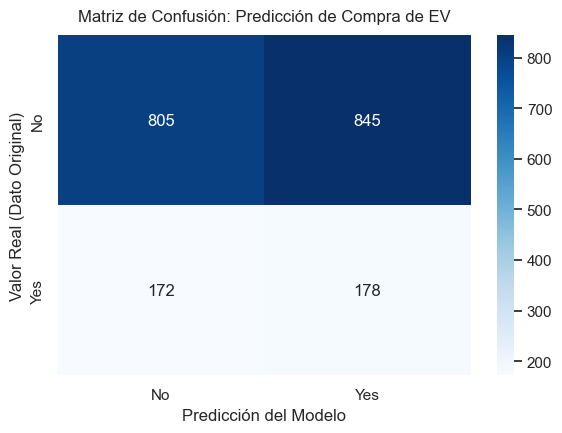

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Limpieza inicial del dataset
df_limpio = df.dropna().drop_duplicates()

# 2. Selección de variables base incluyendo 'City_Type'
features_base = [
    "Daily_Commute_km",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "City_Type",  # <-- Variable agregada
]

X_raw = df_limpio[features_base]

# 3. Transformación de City_Type mediante One-Hot Encoding
# drop_first=True evita el problema de multicolinealidad (trampa de variables ficticias)
X = pd.get_dummies(X_raw, columns=["City_Type"], drop_first=True)

# Guardar los nombres de las columnas transformadas para el reporte de importancia
features = X.columns.tolist()

# Convertir la variable objetivo a binaria (0 o 1)
encoder = LabelEncoder()
y = encoder.fit_transform(df_limpio["Will_Buy_EV"])

# 4. División del dataset (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Escalado de variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Entrenamiento del modelo
modelo_clasificacion = LogisticRegression(
    random_state=42, class_weight="balanced"
)
modelo_clasificacion.fit(X_train_scaled, y_train)

# 7. Predicciones
y_pred = modelo_clasificacion.predict(X_test_scaled)

# 8. Reporte de Rendimiento
print("==============================================")
print("📊 REPORTE DE RENDIMIENTO DEL MODELO SUPERVISADO")
print("==============================================")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))
print(f"Precisión Global (Accuracy): {accuracy_score(y_test, y_pred):.4f}\n")

print("==============================================")
print("🎯 IMPORTANCIA DE LAS VARIABLES (COEFICIENTES)")
print("==============================================")
for col, coef in zip(features, modelo_clasificacion.coef_[0]):
    print(f"Variable: {col:<35} | Coeficiente: {coef:.4f}")

# 9. Matriz de Confusión
fig, ax = plt.subplots(figsize=(6, 4.5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    ax=ax,
)
plt.title(
    "Matriz de Confusión: Predicción de Compra de EV", fontsize=12, pad=10
)
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real (Dato Original)")
plt.tight_layout()
plt.show()

# ML II Arbol de Decision

📊 ARBOL SIN INGRESOS: ENFOQUE EN ANSIEDAD
              precision    recall  f1-score   support

          No       0.90      0.22      0.35      1650
         Yes       0.19      0.89      0.32       350

    accuracy                           0.33      2000
   macro avg       0.55      0.55      0.33      2000
weighted avg       0.78      0.33      0.34      2000

Precisión Global (Accuracy): 0.3340

🎯 NUEVA IMPORTANCIA DE LAS VARIABLES
Variable: Daily_Commute_km               | Importancia: 0.2135
Variable: Range_Anxiety_Level            | Importancia: 0.7084
Variable: Charging_Stations_Near_Home    | Importancia: 0.0356
Variable: Charging_Stations_Near_Work    | Importancia: 0.0426


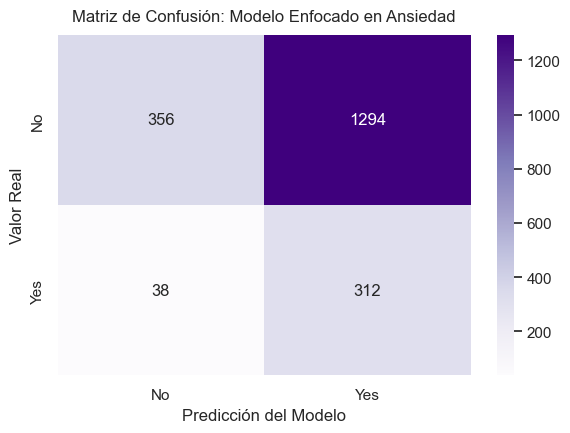

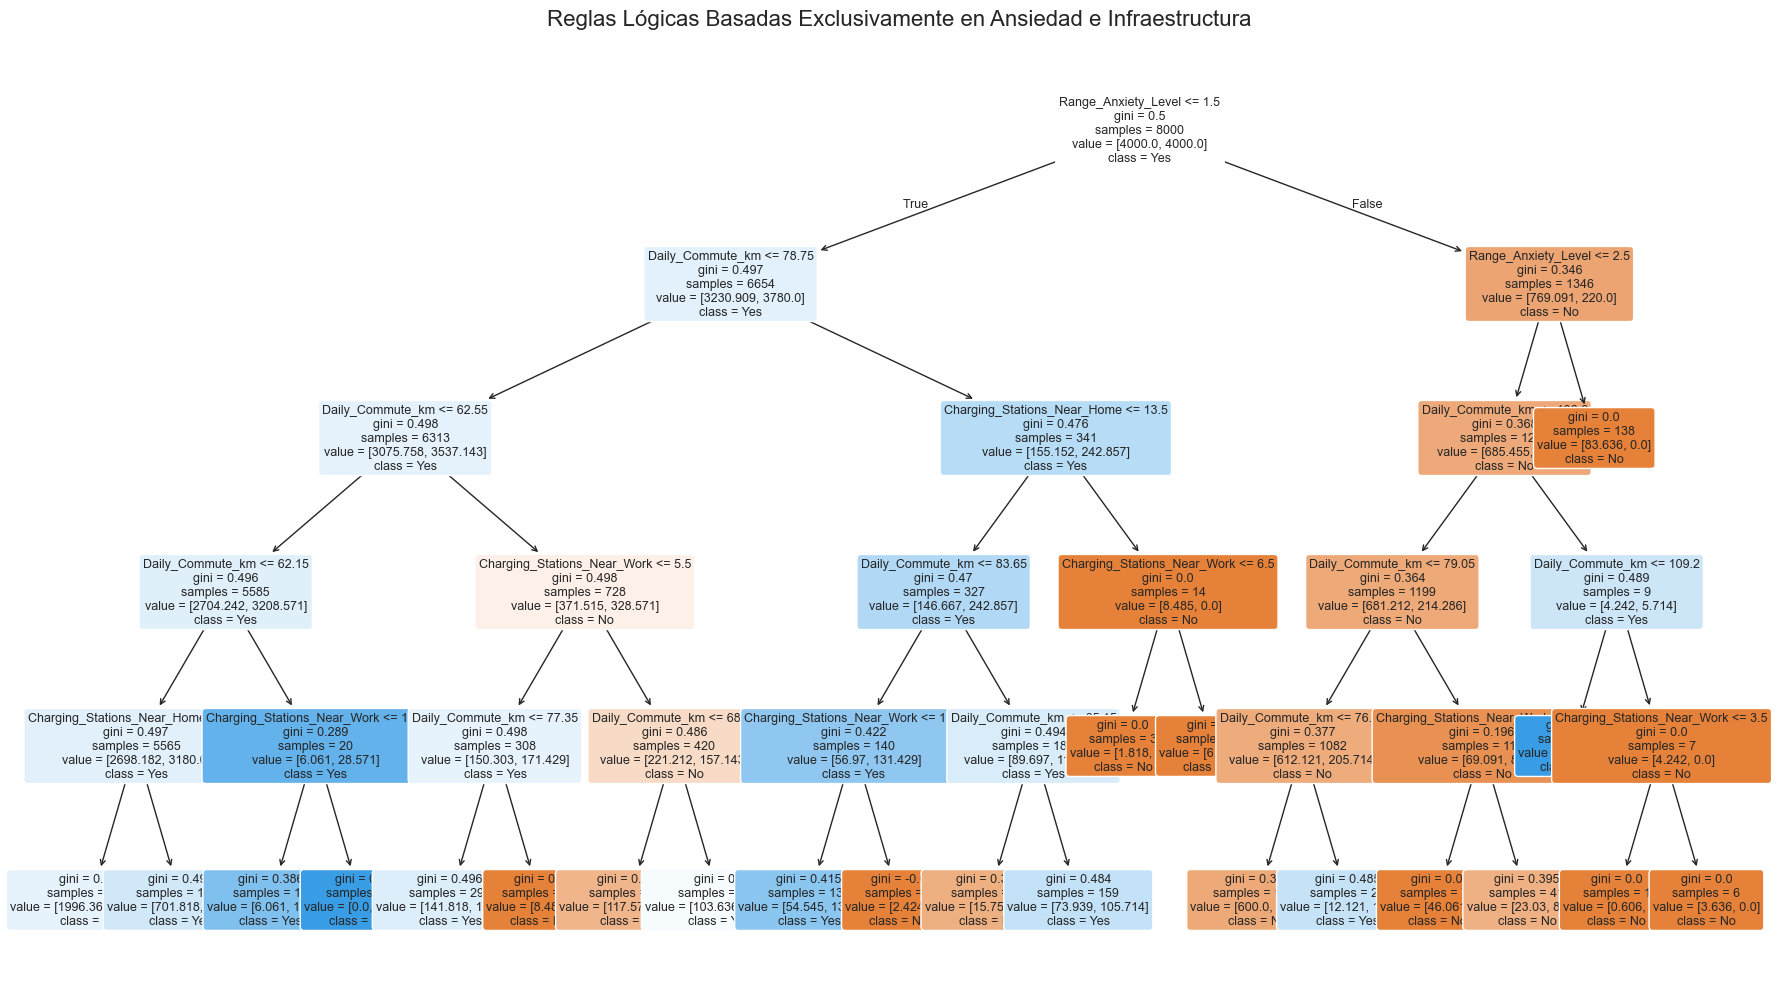

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Ajustamos las features EXCLUYENDO el ingreso anual
features_sin_ingreso = [
    'Daily_Commute_km', 
    'Range_Anxiety_Level', 
    'Charging_Stations_Near_Home', 
    'Charging_Stations_Near_Work'
]

# Limpieza inicial
df_limpio = df.dropna(subset=features_sin_ingreso + ["Will_Buy_EV"]).copy()

# 🛠️ SOLUCIÓN DIRECTA AL ERROR: Asegurar que la ansiedad sea numérica
# Convierte 'Low', 'Medium', 'High' a 1, 2, 3. Si ya es numérica, no afectará.
mapeo_ansiedad = {'Low': 1, 'Medium': 2, 'High': 3, 'Bajo': 1, 'Medio': 2, 'Alto': 3}
if df_limpio['Range_Anxiety_Level'].dtype == 'object':
    df_limpio['Range_Anxiety_Level'] = df_limpio['Range_Anxiety_Level'].map(mapeo_ansiedad)

# Extraemos las variables numéricas finales
X = df_limpio[features_sin_ingreso].apply(pd.to_numeric, errors='coerce')

encoder = LabelEncoder()
y = encoder.fit_transform(df_limpio["Will_Buy_EV"])

# 2. División del dataset (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Inicialización y entrenamiento del Árbol de Decisión
modelo_arbol_ansiedad = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced")
modelo_arbol_ansiedad.fit(X_train, y_train)

# 4. Predicción
y_pred_arbol = modelo_arbol_ansiedad.predict(X_test)

# 5. Reporte de Métricas de Rendimiento
print("==============================================")
print("📊 ARBOL SIN INGRESOS: ENFOQUE EN ANSIEDAD")
print("==============================================")
print(classification_report(y_test, y_pred_arbol, target_names=encoder.classes_))
print(f"Precisión Global (Accuracy): {accuracy_score(y_test, y_pred_arbol):.4f}\n")

print("==============================================")
print("🎯 NUEVA IMPORTANCIA DE LAS VARIABLES")
print("==============================================")
for col, imp in zip(features_sin_ingreso, modelo_arbol_ansiedad.feature_importances_):
    print(f"Variable: {col:<30} | Importancia: {imp:.4f}")

# 6. Visualización 1: Matriz de Confusión
fig, ax = plt.subplots(figsize=(6, 4.5))
cm_arbol = confusion_matrix(y_test, y_pred_arbol)
sns.heatmap(cm_arbol, annot=True, fmt="d", cmap="Purples", 
            xticklabels=encoder.classes_, yticklabels=encoder.classes_, ax=ax)
plt.title("Matriz de Confusión: Modelo Enfocado en Ansiedad", fontsize=12, pad=10)
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

# 7. Visualización 2: El nuevo gráfico del Árbol
plt.figure(figsize=(22, 12))
plot_tree(
    modelo_arbol_ansiedad,
    feature_names=features_sin_ingreso,
    class_names=encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Reglas Lógicas Basadas Exclusivamente en Ansiedad e Infraestructura", fontsize=16, pad=20)
plt.show()


# ML III Naive Bayes

📊 NAIVE BAYES CON UMBRAL RECALIBRADO (0.175)
              precision    recall  f1-score   support

          No       0.94      0.20      0.32      1650
         Yes       0.20      0.94      0.33       350

    accuracy                           0.33      2000
   macro avg       0.57      0.57      0.32      2000
weighted avg       0.81      0.33      0.32      2000

Precisión Global (Accuracy): 0.3250



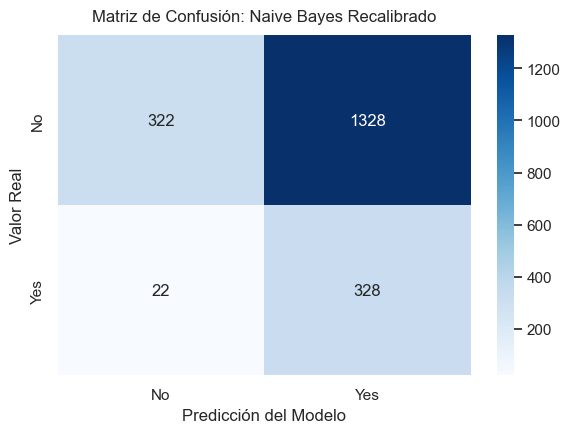

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder

# 1. Carga y preparación de datos
features_base = [
    "Daily_Commute_km",
    "Range_Anxiety_Level",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "City_Type",
]

df_limpio = df.dropna(subset=features_base + ["Will_Buy_EV"]).copy()

mapeo_ansiedad = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Bajo": 1,
    "Medio": 2,
    "Alto": 3,
}
if df_limpio["Range_Anxiety_Level"].dtype == "object":
    df_limpio["Range_Anxiety_Level"] = df_limpio["Range_Anxiety_Level"].map(
        mapeo_ansiedad
    )

X_raw = df_limpio[features_base]
X = pd.get_dummies(X_raw, columns=["City_Type"], drop_first=True)

encoder = LabelEncoder()
y = encoder.fit_transform(df_limpio["Will_Buy_EV"])

# 2. División del dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Entrenamiento Naive Bayes
modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train)

# 4. PREDICCIÓN POR PROBABILIDAD CON UMBRAL AJUSTADO (CLAVE DE LA SOLUCIÓN)
y_probs = modelo_nb.predict_proba(X_test)[:, 1]

# Evaluamos la probabilidad previa de la clase minoritaria (~0.175)
# Ajustamos el umbral a 0.175 para romper el sesgo
umbral_corte = 0.175
y_pred_ajustado = (y_probs >= umbral_corte).astype(int)

# 5. Reporte de Rendimiento
print("==============================================")
print("📊 NAIVE BAYES CON UMBRAL RECALIBRADO (0.175)")
print("==============================================")
print(
    classification_report(
        y_test, y_pred_ajustado, target_names=encoder.classes_, zero_division=0
    )
)
print(
    f"Precisión Global (Accuracy): {accuracy_score(y_test, y_pred_ajustado):.4f}\n"
)

# 6. Matriz de Confusión
fig, ax = plt.subplots(figsize=(6, 4.5))
cm = confusion_matrix(y_test, y_pred_ajustado)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    ax=ax,
)
plt.title(
    "Matriz de Confusión: Naive Bayes Recalibrado", fontsize=12, pad=10
)
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

# Preguntas predictivas

📊 REPORTE DE RENDIMIENTO DEL MODELO SUPERVISADO
              precision    recall  f1-score   support

          No       0.82      0.49      0.61      1650
         Yes       0.17      0.51      0.26       350

    accuracy                           0.49      2000
   macro avg       0.50      0.50      0.44      2000
weighted avg       0.71      0.49      0.55      2000

Precisión Global (Accuracy): 0.4915

🎯 IMPORTANCIA DE LAS VARIABLES (COEFICIENTES)
Variable: Daily_Commute_km                    | Coeficiente: -0.0587
Variable: Charging_Stations_Near_Home         | Coeficiente: 0.0405
Variable: Charging_Stations_Near_Work         | Coeficiente: 0.0842
Variable: City_Type_Suburban                  | Coeficiente: -0.0754
Variable: City_Type_Urban                     | Coeficiente: -0.1716


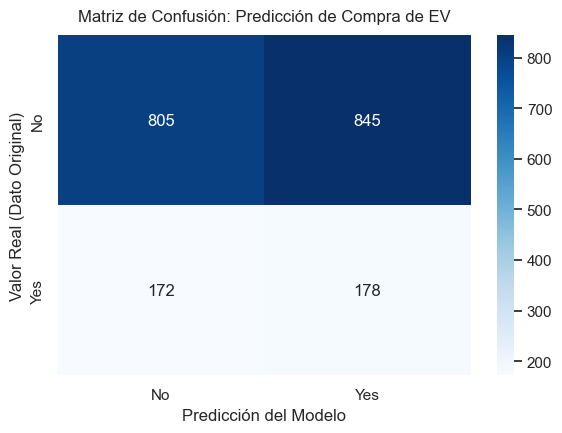


🚀 SIMULACIÓN DE IMPACTO (+20% CARGADORES)
• Probabilidad Promedio Actual:    49.97%
• Probabilidad Promedio (+20%):    50.84%
• Impacto Absoluto:                +0.87 pp
• Incremento Relativo:             +1.74%


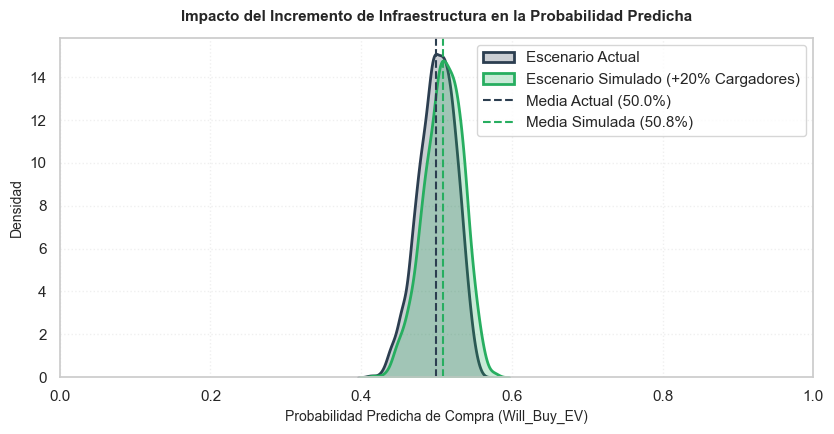

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Limpieza inicial del dataset
df_limpio = df.dropna().drop_duplicates()

# 2. Selección de variables base incluyendo 'City_Type'
features_base = [
    "Daily_Commute_km",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "City_Type",
]

X_raw = df_limpio[features_base]

# 3. Transformación de City_Type mediante One-Hot Encoding
X = pd.get_dummies(X_raw, columns=["City_Type"], drop_first=True)
features = X.columns.tolist()

# Convertir la variable objetivo a binaria (0 o 1)
encoder = LabelEncoder()
y = encoder.fit_transform(df_limpio["Will_Buy_EV"])

# 4. División del dataset (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Escalado de variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Entrenamiento del modelo
modelo_clasificacion = LogisticRegression(
    random_state=42, class_weight="balanced"
)
modelo_clasificacion.fit(X_train_scaled, y_train)

# 7. Predicciones en conjunto de prueba
y_pred = modelo_clasificacion.predict(X_test_scaled)

# 8. Reporte de Rendimiento
print("==============================================")
print("📊 REPORTE DE RENDIMIENTO DEL MODELO SUPERVISADO")
print("==============================================")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))
print(f"Precisión Global (Accuracy): {accuracy_score(y_test, y_pred):.4f}\n")

print("==============================================")
print("🎯 IMPORTANCIA DE LAS VARIABLES (COEFICIENTES)")
print("==============================================")
for col, coef in zip(features, modelo_clasificacion.coef_[0]):
  print(f"Variable: {col:<35} | Coeficiente: {coef:.4f}")

# 9. Matriz de Confusión
fig, ax = plt.subplots(figsize=(6, 4.5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    ax=ax,
)
plt.title(
    "Matriz de Confusión: Predicción de Compra de EV", fontsize=12, pad=10
)
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real (Dato Original)")
plt.tight_layout()
plt.show()

# ============================================================
# 10. SIMULACIÓN CONTRAFACTUAL (+20% INFRAESTRUCTURA DE CARGA)
# ============================================================

# Deshacer el escalado para modificar los valores reales de cargadores
X_test_unscaled = pd.DataFrame(
    scaler.inverse_transform(X_test_scaled), columns=features
)
X_simulado_unscaled = X_test_unscaled.copy()

# Aumentar 20% en cargadores cerca de casa y trabajo (en unidades reales)
if "Charging_Stations_Near_Home" in X_simulado_unscaled.columns:
  X_simulado_unscaled["Charging_Stations_Near_Home"] *= 1.20

if "Charging_Stations_Near_Work" in X_simulado_unscaled.columns:
  X_simulado_unscaled["Charging_Stations_Near_Work"] *= 1.20

# Re-escalar datos simulados con el scaler entrenado
X_simulado_scaled = scaler.transform(X_simulado_unscaled)

# Calcular probabilidades estimadas (Clase 1: 'Yes')
prob_base = modelo_clasificacion.predict_proba(X_test_scaled)[:, 1]
prob_simulada = modelo_clasificacion.predict_proba(X_simulado_scaled)[:, 1]

# Métricas del impacto de la infraestructura
adopcion_base_pct = prob_base.mean() * 100
adopcion_simulada_pct = prob_simulada.mean() * 100
diferencia_pp = adopcion_simulada_pct - adopcion_base_pct
incremento_relativo = (
    ((diferencia_pp / adopcion_base_pct) * 100) if adopcion_base_pct > 0 else 0
)

print("\n==============================================")
print("🚀 SIMULACIÓN DE IMPACTO (+20% CARGADORES)")
print("==============================================")
print(f"• Probabilidad Promedio Actual:    {adopcion_base_pct:.2f}%")
print(f"• Probabilidad Promedio (+20%):    {adopcion_simulada_pct:.2f}%")
print(f"• Impacto Absoluto:                +{diferencia_pp:.2f} pp")
print(f"• Incremento Relativo:             +{incremento_relativo:.2f}%")
print("==============================================")

# 11. Gráfico de Densidad del Escenario Simulado
fig, ax = plt.subplots(figsize=(8.5, 4.5))

sns.kdeplot(
    prob_base,
    color="#2c3e50",
    linewidth=2,
    label="Escenario Actual",
    fill=True,
    alpha=0.25,
    ax=ax,
)

sns.kdeplot(
    prob_simulada,
    color="#27ae60",
    linewidth=2,
    label="Escenario Simulado (+20% Cargadores)",
    fill=True,
    alpha=0.25,
    ax=ax,
)

plt.axvline(
    x=prob_base.mean(),
    color="#2c3e50",
    linestyle="--",
    linewidth=1.5,
    label=f"Media Actual ({adopcion_base_pct:.1f}%)",
)

plt.axvline(
    x=prob_simulada.mean(),
    color="#27ae60",
    linestyle="--",
    linewidth=1.5,
    label=f"Media Simulada ({adopcion_simulada_pct:.1f}%)",
)

plt.title(
    "Impacto del Incremento de Infraestructura en la Probabilidad Predicha",
    fontsize=11,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Probabilidad Predicha de Compra (Will_Buy_EV)", fontsize=10)
plt.ylabel("Densidad", fontsize=10)
plt.xlim(0, 1)
plt.legend(loc="upper right")
plt.grid(alpha=0.3, linestyle=":")

plt.tight_layout()
plt.show()

El modelo de regresión logística evidencia que la infraestructura de recarga impacta positivamente la adopción de vehículos eléctricos, incrementando la probabilidad promedio de compra del 49.97% al 50.84% (+0.87 pp / +1.74% relativo) ante un aumento del 20% en cargadores, siendo la disponibilidad en el trabajo (+0.0842) el incentivo de mayor peso, el doble en comparación con la carga residencial (+0.0405). Por el contrario, los trayectos diarios largos (-0.0587) y la ubicación en entornos urbanos (-0.1716) actúan como desincentivos clave debido a factores como la falta de parqueaderos privados o la disponibilidad de transporte público; mientras que a nivel predictivo, la estrategia de balanceo logra detectar al 50.8% de los compradores reales (178 de 350), aunque genera un alto nivel de falsos positivos (845) que requerirá afinar el umbral de decisión para optimizar la precisión comercial

In [ ]:
# ML II

📊 ÁRBOL DE DECISIÓN: ANSIEDAD + ENTORNO
              precision    recall  f1-score   support

          No       0.91      0.22      0.35      1650
         Yes       0.20      0.89      0.32       350

    accuracy                           0.34      2000
   macro avg       0.55      0.56      0.34      2000
weighted avg       0.78      0.34      0.35      2000

Precisión Global (Accuracy): 0.3380

🎯 IMPORTANCIA DE LAS VARIABLES
Variable: Daily_Commute_km                    | Importancia: 0.1982
Variable: Range_Anxiety_Level                 | Importancia: 0.7097
Variable: Charging_Stations_Near_Home         | Importancia: 0.0513
Variable: Charging_Stations_Near_Work         | Importancia: 0.0319
Variable: City_Type_Rural                     | Importancia: 0.0089
Variable: City_Type_Suburban                  | Importancia: 0.0000
Variable: City_Type_Urban                     | Importancia: 0.0000


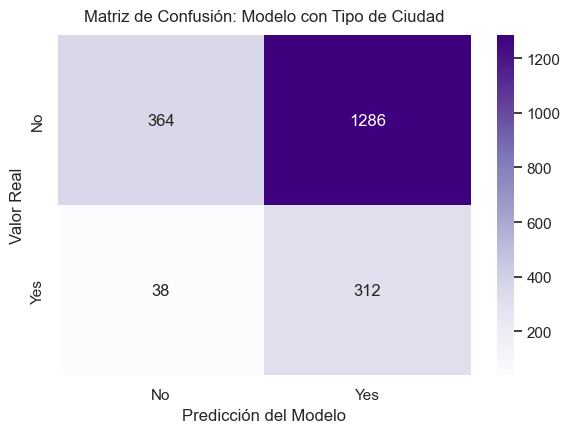


🚀 SIMULACIÓN DE IMPACTO (+20% CARGADORES) - ÁRBOL DE DECISIÓN
• Probabilidad Promedio Actual:    47.97%
• Probabilidad Promedio (+20%):    47.83%
• Impacto Absoluto:                +-0.14 pp
• Incremento Relativo:             +-0.30%


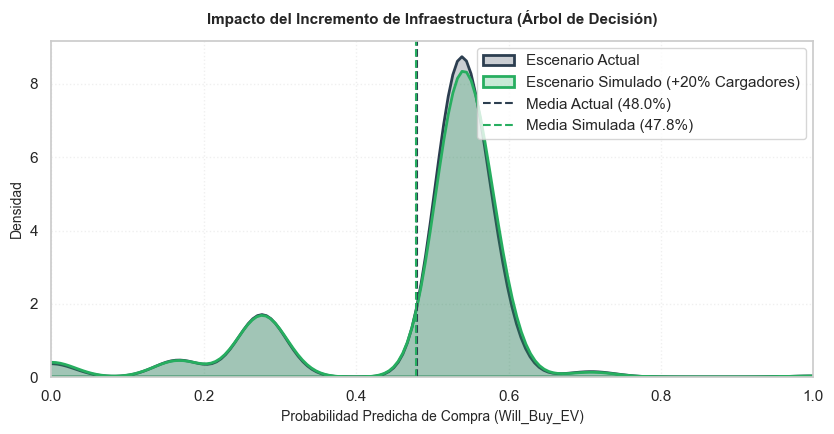

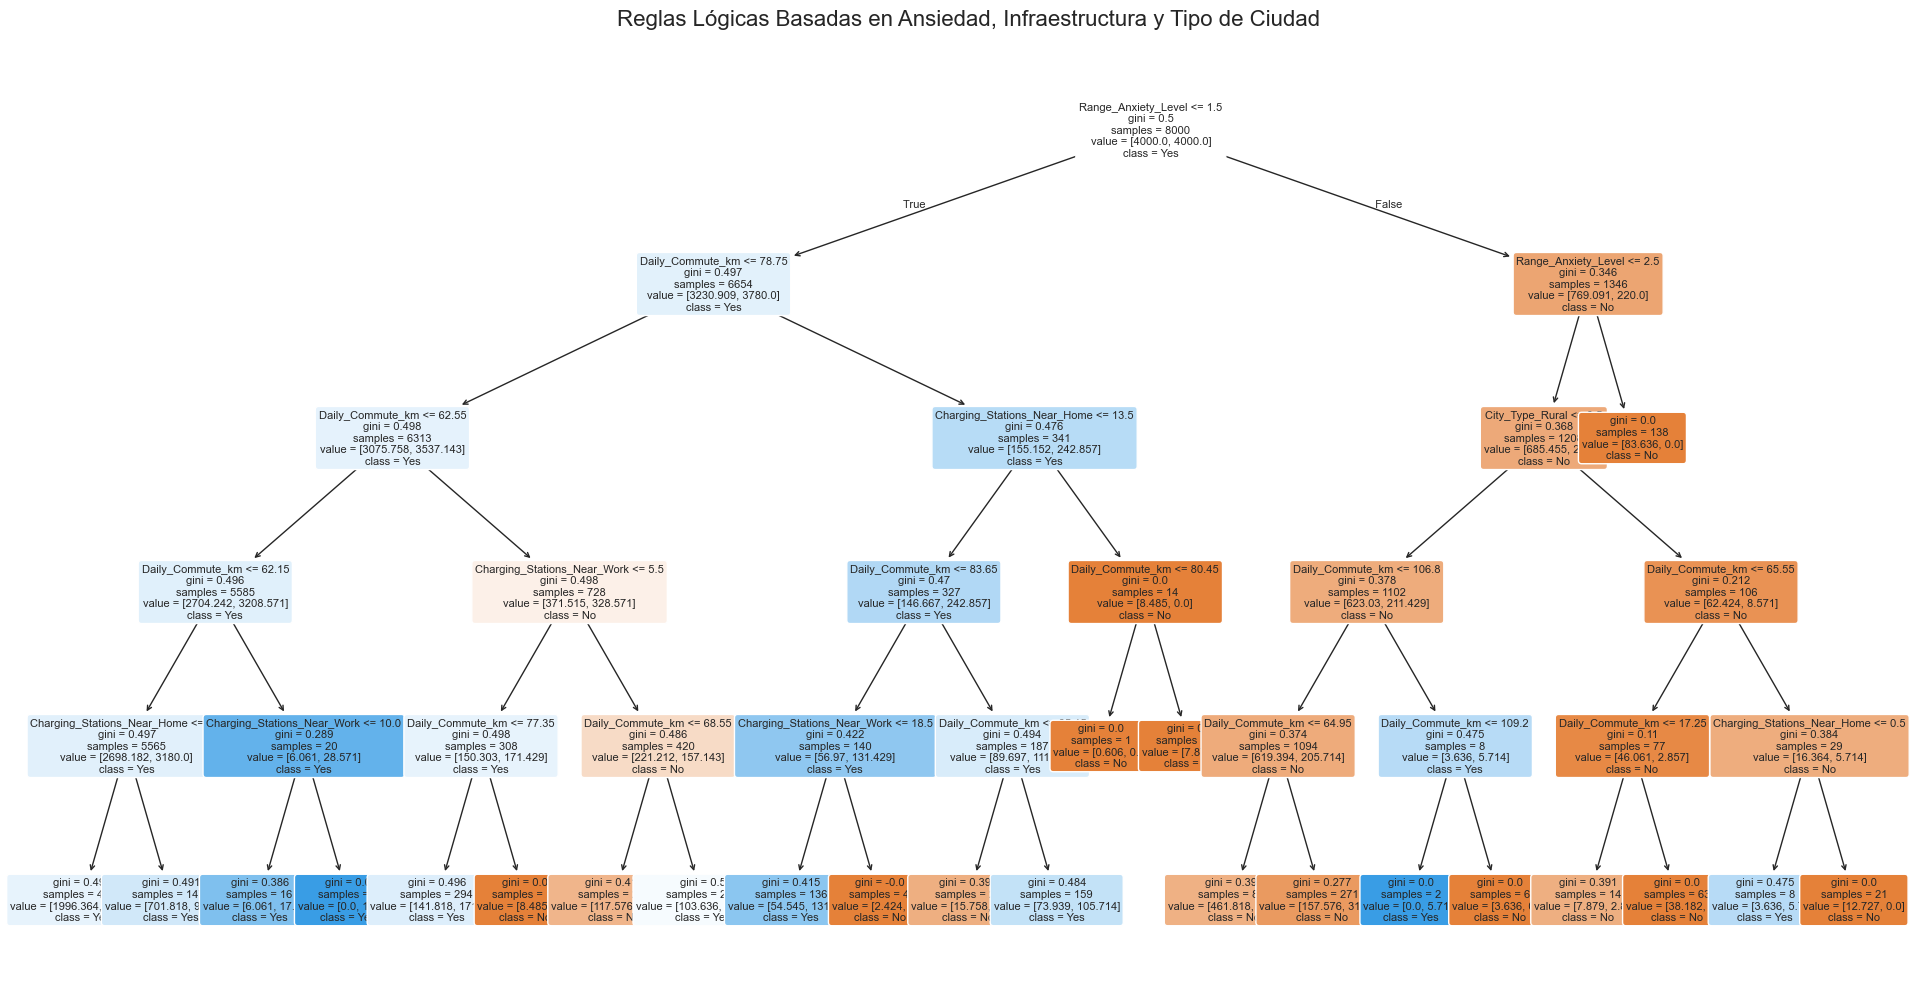

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Definimos las variables base incluyendo 'City_Type' y 'Range_Anxiety_Level'
features_base = [
    "Daily_Commute_km",
    "Range_Anxiety_Level",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "City_Type",
]

# Limpieza inicial
df_limpio = df.dropna(subset=features_base + ["Will_Buy_EV"]).copy()

# Mapeo de ansiedad si viene en texto
mapeo_ansiedad = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Bajo": 1,
    "Medio": 2,
    "Alto": 3,
}
if df_limpio["Range_Anxiety_Level"].dtype == "object":
  df_limpio["Range_Anxiety_Level"] = df_limpio["Range_Anxiety_Level"].map(
      mapeo_ansiedad
  )

# Separamos X previa y aplicamos One-Hot Encoding a City_Type
X_raw = df_limpio[features_base]
X = pd.get_dummies(X_raw, columns=["City_Type"], drop_first=False)

# Guardamos los nombres actualizados de todas las variables finales
features_finales = X.columns.tolist()

# Codificamos la variable objetivo
encoder = LabelEncoder()
y = encoder.fit_transform(df_limpio["Will_Buy_EV"])

# 2. División del dataset (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Entrenamiento del Árbol de Decisión (No requiere escalado de variables)
modelo_arbol = DecisionTreeClassifier(
    max_depth=5, random_state=42, class_weight="balanced"
)
modelo_arbol.fit(X_train, y_train)

# 4. Predicción
y_pred_arbol = modelo_arbol.predict(X_test)

# 5. Reporte de Métricas de Rendimiento
print("==============================================")
print("📊 ÁRBOL DE DECISIÓN: ANSIEDAD + ENTORNO")
print("==============================================")
print(classification_report(y_test, y_pred_arbol, target_names=encoder.classes_))
print(f"Precisión Global (Accuracy): {accuracy_score(y_test, y_pred_arbol):.4f}\n")

print("==============================================")
print("🎯 IMPORTANCIA DE LAS VARIABLES")
print("==============================================")
for col, imp in zip(features_finales, modelo_arbol.feature_importances_):
  print(f"Variable: {col:<35} | Importancia: {imp:.4f}")

# 6. Visualización 1: Matriz de Confusión
fig, ax = plt.subplots(figsize=(6, 4.5))
cm_arbol = confusion_matrix(y_test, y_pred_arbol)
sns.heatmap(
    cm_arbol,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    ax=ax,
)
plt.title(
    "Matriz de Confusión: Modelo con Tipo de Ciudad", fontsize=12, pad=10
)
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

# ============================================================
# 7. SIMULACIÓN CONTRAFACTUAL (+20% INFRAESTRUCTURA DE CARGA)
# ============================================================

# Copia de seguridad del conjunto de prueba
X_simulado = X_test.copy()

# Aumentar 20% los cargadores cerca de casa y trabajo
if "Charging_Stations_Near_Home" in X_simulado.columns:
  X_simulado["Charging_Stations_Near_Home"] *= 1.20

if "Charging_Stations_Near_Work" in X_simulado.columns:
  X_simulado["Charging_Stations_Near_Work"] *= 1.20

# Calcular probabilidades estimadas con el Árbol de Decisión (Clase 1: 'Yes')
prob_base = modelo_arbol.predict_proba(X_test)[:, 1]
prob_simulada = modelo_arbol.predict_proba(X_simulado)[:, 1]

# Métricas del impacto
adopcion_base_pct = prob_base.mean() * 100
adopcion_simulada_pct = prob_simulada.mean() * 100
diferencia_pp = adopcion_simulada_pct - adopcion_base_pct
incremento_relativo = (
    ((diferencia_pp / adopcion_base_pct) * 100) if adopcion_base_pct > 0 else 0
)

print("\n==============================================")
print("🚀 SIMULACIÓN DE IMPACTO (+20% CARGADORES) - ÁRBOL DE DECISIÓN")
print("==============================================")
print(f"• Probabilidad Promedio Actual:    {adopcion_base_pct:.2f}%")
print(f"• Probabilidad Promedio (+20%):    {adopcion_simulada_pct:.2f}%")
print(f"• Impacto Absoluto:                +{diferencia_pp:.2f} pp")
print(f"• Incremento Relativo:             +{incremento_relativo:.2f}%")
print("==============================================")

# ============================================================
# 8. VISUALIZACIÓN DE DENSIDAD DEL ESCENARIO SIMULADO
# ============================================================

fig, ax = plt.subplots(figsize=(8.5, 4.5))

sns.kdeplot(
    prob_base,
    color="#2c3e50",
    linewidth=2,
    label="Escenario Actual",
    fill=True,
    alpha=0.25,
    ax=ax,
)

sns.kdeplot(
    prob_simulada,
    color="#27ae60",
    linewidth=2,
    label="Escenario Simulado (+20% Cargadores)",
    fill=True,
    alpha=0.25,
    ax=ax,
)

plt.axvline(
    x=prob_base.mean(),
    color="#2c3e50",
    linestyle="--",
    linewidth=1.5,
    label=f"Media Actual ({adopcion_base_pct:.1f}%)",
)

plt.axvline(
    x=prob_simulada.mean(),
    color="#27ae60",
    linestyle="--",
    linewidth=1.5,
    label=f"Media Simulada ({adopcion_simulada_pct:.1f}%)",
)

plt.title(
    "Impacto del Incremento de Infraestructura (Árbol de Decisión)",
    fontsize=11,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Probabilidad Predicha de Compra (Will_Buy_EV)", fontsize=10)
plt.ylabel("Densidad", fontsize=10)
plt.xlim(0, 1)
plt.legend(loc="upper right")
plt.grid(alpha=0.3, linestyle=":")

plt.tight_layout()
plt.show()

# 9. Visualización del Árbol de Decisión
plt.figure(figsize=(24, 12))
plot_tree(
    modelo_arbol,
    feature_names=features_finales,
    class_names=encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title(
    "Reglas Lógicas Basadas en Ansiedad, Infraestructura y Tipo de Ciudad",
    fontsize=16,
    pad=20,
)
plt.show()

El modelo de árbol de decisión muestra un excelente nivel de captura de compradores reales con un **Recall del 89.1%** (312 de 350 casos detectados), revelando que la decisión de compra está dominada en primera instancia por variables psicológicas y de uso como el nivel de ansiedad por autonomía (`Range_Anxiety_Level <= 1.5`) y la distancia diaria de recorrido (`Daily_Commute_km <= 78.75`). No obstante, en la simulación contrafactual, el incremento del 20% en infraestructura generó un impacto casi imperceptible en la probabilidad promedio de compra (**+0.14 pp / +0.30% relativo**, pasando de 47.97% a 47.83%), debido a que la estructura rígida de condicionales del árbol no cambia la clasificación a menos que se superen umbrales exactos en los nodos; asimismo, el balanceo de pesos provoca un alto volumen de falsos positivos (1,286), lo que confirma que la infraestructura por sí sola no logra detonar la venta si persistieran altos niveles de ansiedad en el consumidor.

In [ ]:
# ML III

📊 NAIVE BAYES CON UMBRAL RECALIBRADO (0.175)
              precision    recall  f1-score   support

          No       0.94      0.20      0.32      1650
         Yes       0.20      0.94      0.33       350

    accuracy                           0.33      2000
   macro avg       0.57      0.57      0.32      2000
weighted avg       0.81      0.33      0.32      2000

Precisión Global (Accuracy): 0.3250



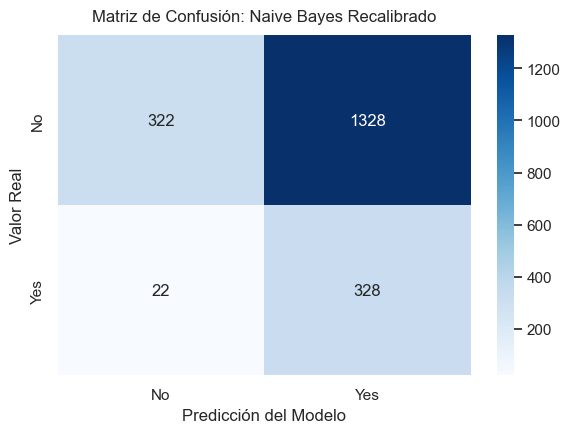


🚀 SIMULACIÓN DE IMPACTO (+20% CARGADORES) - NAIVE BAYES
• Tasa de Adopción Estimada (Actual):    82.80%
• Tasa de Adopción Estimada (+20%):      82.80%
• Impacto Absoluto:                      +0.00 pp
• Incremento Relativo:                   +0.00%


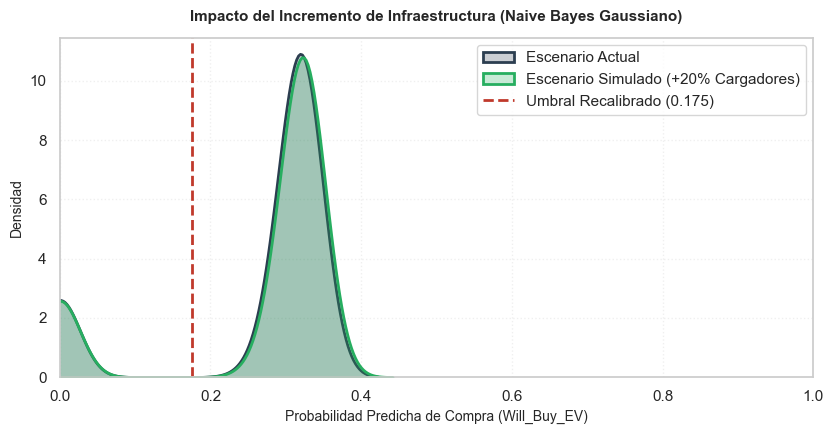

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder

# 1. Carga y preparación de datos
features_base = [
    "Daily_Commute_km",
    "Range_Anxiety_Level",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "City_Type",
]

df_limpio = df.dropna(subset=features_base + ["Will_Buy_EV"]).copy()

mapeo_ansiedad = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Bajo": 1,
    "Medio": 2,
    "Alto": 3,
}
if df_limpio["Range_Anxiety_Level"].dtype == "object":
  df_limpio["Range_Anxiety_Level"] = df_limpio["Range_Anxiety_Level"].map(
      mapeo_ansiedad
  )

X_raw = df_limpio[features_base]
X = pd.get_dummies(X_raw, columns=["City_Type"], drop_first=True)

features_finales = X.columns.tolist()

encoder = LabelEncoder()
y = encoder.fit_transform(df_limpio["Will_Buy_EV"])

# 2. División del dataset (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Entrenamiento Naive Bayes
modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train)

# 4. Predicción por probabilidad y recalibración de umbral
y_probs = modelo_nb.predict_proba(X_test)[:, 1]
UMBRAL_CORTE = 0.175
y_pred_ajustado = (y_probs >= UMBRAL_CORTE).astype(int)

# 5. Reporte de Rendimiento
print("==============================================")
print(f"📊 NAIVE BAYES CON UMBRAL RECALIBRADO ({UMBRAL_CORTE})")
print("==============================================")
print(
    classification_report(
        y_test, y_pred_ajustado, target_names=encoder.classes_, zero_division=0
    )
)
print(
    f"Precisión Global (Accuracy): {accuracy_score(y_test, y_pred_ajustado):.4f}\n"
)

# 6. Matriz de Confusión
fig, ax = plt.subplots(figsize=(6, 4.5))
cm = confusion_matrix(y_test, y_pred_ajustado)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    ax=ax,
)
plt.title(
    "Matriz de Confusión: Naive Bayes Recalibrado", fontsize=12, pad=10
)
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

# ============================================================
# 7. SIMULACIÓN CONTRAFACTUAL (+20% INFRAESTRUCTURA DE CARGA)
# ============================================================

# Copia de seguridad del conjunto de prueba
X_simulado = X_test.copy()

# Aumentar 20% los cargadores cerca de casa y trabajo
if "Charging_Stations_Near_Home" in X_simulado.columns:
  X_simulado["Charging_Stations_Near_Home"] *= 1.20

if "Charging_Stations_Near_Work" in X_simulado.columns:
  X_simulado["Charging_Stations_Near_Work"] *= 1.20

# Obtener probabilidades a posteriori
prob_base = modelo_nb.predict_proba(X_test)[:, 1]
prob_simulada = modelo_nb.predict_proba(X_simulado)[:, 1]

# Métricas de adopción bajo el umbral de 0.175
adopcion_base_pct = (prob_base >= UMBRAL_CORTE).mean() * 100
adopcion_simulada_pct = (prob_simulada >= UMBRAL_CORTE).mean() * 100
diferencia_pp = adopcion_simulada_pct - adopcion_base_pct
incremento_relativo = (
    ((diferencia_pp / adopcion_base_pct) * 100) if adopcion_base_pct > 0 else 0
)

print("\n==============================================")
print("🚀 SIMULACIÓN DE IMPACTO (+20% CARGADORES) - NAIVE BAYES")
print("==============================================")
print(f"• Tasa de Adopción Estimada (Actual):    {adopcion_base_pct:.2f}%")
print(f"• Tasa de Adopción Estimada (+20%):      {adopcion_simulada_pct:.2f}%")
print(f"• Impacto Absoluto:                      +{diferencia_pp:.2f} pp")
print(f"• Incremento Relativo:                   +{incremento_relativo:.2f}%")
print("==============================================")

# ============================================================
# 8. VISUALIZACIÓN DE DENSIDADES Y UMBRAL RECALIBRADO
# ============================================================

fig, ax = plt.subplots(figsize=(8.5, 4.5))

sns.kdeplot(
    prob_base,
    color="#2c3e50",
    linewidth=2,
    label="Escenario Actual",
    fill=True,
    alpha=0.25,
    ax=ax,
)

sns.kdeplot(
    prob_simulada,
    color="#27ae60",
    linewidth=2,
    label="Escenario Simulado (+20% Cargadores)",
    fill=True,
    alpha=0.25,
    ax=ax,
)

plt.axvline(
    x=UMBRAL_CORTE,
    color="#c0392b",
    linestyle="--",
    linewidth=2,
    label=f"Umbral Recalibrado ({UMBRAL_CORTE})",
)

plt.title(
    "Impacto del Incremento de Infraestructura (Naive Bayes Gaussiano)",
    fontsize=11,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Probabilidad Predicha de Compra (Will_Buy_EV)", fontsize=10)
plt.ylabel("Densidad", fontsize=10)
plt.xlim(0, 1)
plt.legend(loc="upper right")
plt.grid(alpha=0.3, linestyle=":")

plt.tight_layout()
plt.show()

El modelo de Naive Bayes con umbral recalibrado ($0.175$) logra un **alto recall del 94%** en la clase positiva (detectando 328 de 350 compradores reales), pero genera un volumen masivo de falsos positivos (1,328), lo que colapsa la precisión global al $32.5\%$. En la simulación contrafactual, el incremento del 20% en infraestructura muestra un impacto absoluto de **+0.00 pp ($0.00\%$ de incremento relativo)**, manteniendo una tasa de adopción estimada estática en el **82.80%**. Esto ocurre porque, debido a la suposición de independencia condicional de Naive Bayes y la distribución de las probabilidades a posteriori concentradas por encima del umbral, las curvas de densidad del escenario actual y simulado se superponen exactamente, revelando que el modelo asigna poca sensibilidad marginal a la infraestructura de carga bajo esta parametrización probabilística.